### Data import and Packages

In [1]:
# Autonomous Vehicle Incident Severity Prediction
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# NLP libraries
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import gensim
from gensim import corpora
from gensim.models import LdaModel, TfidfModel
import pyLDAvis
import pyLDAvis.gensim_models as gensimvisualize
from gensim.models.coherencemodel import CoherenceModel
from sentence_transformers import SentenceTransformer
from pprint import pprint
nltk.download("punkt")
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
import re
import string

# ML libraries
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import plot_tree

# Imbalanced learning libraries
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline as make_imb_pipeline
from imblearn.ensemble import BalancedRandomForestClassifier

import shap
import numpy as np
import matplotlib.pyplot as plt

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\gabos\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gabos\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\gabos\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\gabos\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


### Helper Functions

In [31]:
def aggregate_areas(row, vehicle_prefix):
    """
    Aggregate impact areas into general regions
    
    Parameters:
    -----------
    row : pd.Series
        Row of data
    vehicle_prefix : str
        Prefix for the vehicle columns ('sv' or 'cp')
    
    Returns:
    --------
    list
        List of general regions with impacts
    """
    general_regions = []
    
    # Check Front regions
    if any(row[f"{vehicle_prefix}_contact_area_-_{area}"] == 1 for area in ["front", "front_left", "front_right"]):
        general_regions.append("Front")
    
    # Check Rear regions
    if any(row[f"{vehicle_prefix}_contact_area_-_{area}"] == 1 for area in ["rear", "rear_left", "rear_right"]):
        general_regions.append("Rear")
    
    # Check Left regions
    if any(row[f"{vehicle_prefix}_contact_area_-_{area}"] == 1 for area in ["left", "front_left", "rear_left"]):
        general_regions.append("Left")
    
    # Check Right regions
    if any(row[f"{vehicle_prefix}_contact_area_-_{area}"] == 1 for area in ["right", "front_right", "rear_right"]):
        general_regions.append("Right")
    
    # Check Top/Bottom
    if row[f"{vehicle_prefix}_contact_area_-_top"] == 1:
        general_regions.append("Top")
    if row[f"{vehicle_prefix}_contact_area_-_bottom"] == 1:
        general_regions.append("Bottom")
    
    return general_regions

def assign_risk_level(row):
    """
    Define risk levels based on injury severity
    
    Parameters:
    -----------
    row : pd.Series
        Row of data with injury severity information
    
    Returns:
    --------
    str
        Risk level classification
    """
    injury = row["highest_injury_severity_alleged"]
    if injury in ["No Injuries Reported", "Unknown"]:
        return "No Injury"
    elif injury == "Minor":
        return "Minor Injury"
    elif injury in ["Moderate", "Severe", "Fatality"]:
        return "Moderate/Severe Injury or Fatality"
    else:
        return "Unknown"
    

def check_missing_values(df):
    # Standard null check (None and np.nan)
    null_count = df.isnull().sum()
    
    # Check for empty strings
    empty_strings = (df == "").sum()
    
    # Check for whitespace-only strings (only for object/string columns)
    whitespace_only = pd.Series(0, index=df.columns)
    for col in df.select_dtypes(include=['object']).columns:
        whitespace_only[col] = df[col].str.isspace().fillna(False).sum()
    
    # Check for common string representations of missing values
    na_strings = pd.Series(0, index=df.columns)
    na_values = ["NA", "N/A", "na", "n/a", "NaN", "nan", "NULL", "null"]
    for col in df.select_dtypes(include=['object']).columns:
        na_strings[col] = df[col].isin(na_values).sum()
    
    # Combine all counts
    total_missing = null_count + empty_strings + whitespace_only + na_strings
    
    return total_missing

def remove_stopwords(incident):
    """
    Return the incident after removing stopwords
    
    Parameters:
    -----------
    incident : str
        Incident narrative text
    
    Returns:
    --------
    str
        Filtered incident text
    """
    stop_words = set(stopwords.words('english'))
    additional_stopwords = [
        'XXX', 'PT', 'AV', 'SUV', 'damage', 'mph', 'collision', 
        'autonomous', 'vehicle', 'San Francisco', 'Mountain View'
    ]
    stop_words.update(additional_stopwords)
    incident_tokens = word_tokenize(incident) 
    filtered_incident = [word for word in incident_tokens if word not in stop_words] 
    return " ".join(filtered_incident)

def preprocess_text(text):
    """
    Preprocess text for topic modeling with enhanced filtering
    """
    # Initialize lemmatizer
    lemmatizer = WordNetLemmatizer()
    
    # Convert to lowercase and remove punctuation
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Enhanced stopwords list with domain-specific terms
    stop_words = set(stopwords.words('english'))
    additional_stopwords = [
        # Your existing stopword list...
        
        # Add the problematic words you mentioned
        'submission', 'order', 'motor', 'reference', 'fact', 'field', 'based',
        'general', 'response', 'lane', 'level', 'become', 'request', 'cruise',
        'submission', 'trailer', 'llc', 'motor', 'fact', 'semi', 'order', 
        'field', 'reference', 
        
        # Common legal/reporting terminology
        'pursuant', 'herein', 'thereof', 'regarding', 'aforementioned',
        'amended', 'amendment', 'file', 'filed', 'filing',
        
        # More document-specific words
        'page', 'section', 'appendix', 'attachment', 'supplement'
    ]
    stop_words.update(additional_stopwords)
    
    # Filter tokens - more aggressive filtering
    filtered_tokens = []
    for word in tokens:
        # Lemmatize the word
        word = lemmatizer.lemmatize(word)
        # Only keep if not a stopword, longer than 2 chars, and not a digit
        if (word not in stop_words and len(word) > 2 and not word.isdigit()):
            filtered_tokens.append(word)
    
    return filtered_tokens

### Data Loading

In [3]:
# Load the data from Excel file
df = pd.read_excel("input/ads.xlsx", sheet_name="SGO-2021-01_Incident_Reports_AD")

# Standardize column names: lowercase and replace spaces with underscores
df.columns = [c.lower().replace(' ', '_') for c in df.columns]

# filtering out trucks
df = df[(df['model'] != 'LT') & (df['model'] != '579')]

# Select relevant features
selected_features = [
    'model_year', 'mileage', 'roadway_type', 'roadway_surface',
    'posted_speed_limit_(mph)', 'lighting', 'weather_-_clear', 'weather_-_snow', 
    'weather_-_cloudy', 'weather_-_fog/smoke', 'weather_-_rain', 'weather_-_severe_wind', 
    'crash_with', 'highest_injury_severity_alleged', 'cp_pre-crash_movement', 
    'cp_contact_area_-_rear_left', 'cp_contact_area_-_left', 'cp_contact_area_-_front_left', 
    'cp_contact_area_-_rear', 'cp_contact_area_-_top', 'cp_contact_area_-_front', 
    'cp_contact_area_-_rear_right', 'cp_contact_area_-_right', 'cp_contact_area_-_front_right', 
    'cp_contact_area_-_bottom', 'sv_pre-crash_movement', 'sv_were_all_passengers_belted?', 
    'sv_precrash_speed_(mph)', 'sv_contact_area_-_rear_left', 'sv_contact_area_-_left', 
    'sv_contact_area_-_front_left', 'sv_contact_area_-_rear', 'sv_contact_area_-_top', 
    'sv_contact_area_-_front', 'sv_contact_area_-_rear_right', 'sv_contact_area_-_right', 
    'sv_contact_area_-_front_right', 'sv_contact_area_-_bottom', 'narrative'
]
data = df.loc[:, selected_features].copy()
print(data.shape)

(1844, 39)


### Data Preprocessing

In [7]:
# Format data types
# Convert string columns
string_columns = [
    'roadway_type', 'roadway_surface', 'lighting', 'crash_with', 
    'highest_injury_severity_alleged', 'cp_pre-crash_movement',
    'sv_pre-crash_movement', 'sv_were_all_passengers_belted?',
    'narrative'
]
data[string_columns] = data[string_columns].astype(str)

# Convert binary indicator columns
binary_columns = [
    'weather_-_clear', 'weather_-_snow', 'weather_-_cloudy', 'weather_-_fog/smoke', 
    'weather_-_rain', 'weather_-_severe_wind', 'cp_contact_area_-_rear_left', 
    'cp_contact_area_-_left', 'cp_contact_area_-_front_left', 'cp_contact_area_-_rear',
    'cp_contact_area_-_top', 'cp_contact_area_-_front', 'cp_contact_area_-_rear_right', 
    'cp_contact_area_-_right', 'cp_contact_area_-_front_right', 'cp_contact_area_-_bottom', 
    'sv_contact_area_-_rear_left', 'sv_contact_area_-_left', 'sv_contact_area_-_front_left', 
    'sv_contact_area_-_rear', 'sv_contact_area_-_top', 'sv_contact_area_-_front',
    'sv_contact_area_-_rear_right', 'sv_contact_area_-_right', 'sv_contact_area_-_front_right', 
    'sv_contact_area_-_bottom'
]
data[binary_columns] = data[binary_columns].replace({'Y': 1, ' ': 0}).astype(int)

# Fill missing values in numeric columns
numeric_columns = ['mileage', 'posted_speed_limit_(mph)', 'sv_precrash_speed_(mph)']
data[numeric_columns] = data[numeric_columns].fillna(0)

# Check for missing values
missing_counts = check_missing_values(data)
print("Columns with any type of missing value:")
print(missing_counts[missing_counts > 0])

Columns with any type of missing value:
model_year                         15
roadway_type                        3
roadway_surface                     3
lighting                            3
crash_with                          3
highest_injury_severity_alleged     3
cp_pre-crash_movement              70
sv_pre-crash_movement               3
sv_were_all_passengers_belted?      3
narrative                           2
dtype: int64


C:\Users\gabos\AppData\Local\Temp\ipykernel_2368\1881104734.py:23: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[binary_columns] = data[binary_columns].replace({'Y': 1, ' ': 0}).astype(int)


### Feature Engineering - Weather and Road

In [8]:
# Process weather features, where weather_condition = 1 if cleaer
data['weather_condition'] = data['weather_-_clear'].astype(int)
columns_to_drop = [
    'weather_-_snow', 'weather_-_clear', 'weather_-_cloudy', 
    'weather_-_fog/smoke', 'weather_-_rain', 'weather_-_severe_wind'
]
data.drop(columns=columns_to_drop, inplace=True)

# Process lighting
lighting_mapping = {'Daylight': 1, 'Dawn / Dusk': 1}
data['lighting'] = data['lighting'].map(lighting_mapping).fillna(0).astype(int)

# Process roadway surface
roadway_surface_mapping = {'Dry': 1}
data['roadway_surface'] = data['roadway_surface'].map(roadway_surface_mapping).fillna(0).astype(int)

# One-hot encode roadway type
dummies = pd.get_dummies(data['roadway_type'], prefix='roadway_type')
dummies.columns = dummies.columns.str.replace(' / ', '_', regex=False).str.replace(' ', '_')
data = pd.concat([data, dummies], axis=1)
data = data.drop('roadway_type', axis=1)

In [9]:
#including in roadtype nan into unknown
data['roadway_type_Unknown'] = data[['roadway_type_Unknown', 'roadway_type_nan']].max(axis=1)
data = data.drop('roadway_type_nan', axis=1)

print(data.columns)

Index(['model_year', 'mileage', 'roadway_surface', 'posted_speed_limit_(mph)',
       'lighting', 'crash_with', 'highest_injury_severity_alleged',
       'cp_pre-crash_movement', 'cp_contact_area_-_rear_left',
       'cp_contact_area_-_left', 'cp_contact_area_-_front_left',
       'cp_contact_area_-_rear', 'cp_contact_area_-_top',
       'cp_contact_area_-_front', 'cp_contact_area_-_rear_right',
       'cp_contact_area_-_right', 'cp_contact_area_-_front_right',
       'cp_contact_area_-_bottom', 'sv_pre-crash_movement',
       'sv_were_all_passengers_belted?', 'sv_precrash_speed_(mph)',
       'sv_contact_area_-_rear_left', 'sv_contact_area_-_left',
       'sv_contact_area_-_front_left', 'sv_contact_area_-_rear',
       'sv_contact_area_-_top', 'sv_contact_area_-_front',
       'sv_contact_area_-_rear_right', 'sv_contact_area_-_right',
       'sv_contact_area_-_front_right', 'sv_contact_area_-_bottom',
       'narrative', 'weather_condition', 'roadway_type_Highway_Freeway',
       'roa

### Feature Engineering - Crash Details

In [10]:
# One-hot encode crash with object
dummies_crash = pd.get_dummies(data['crash_with'], prefix='crash_with')
dummies_crash.columns = dummies_crash.columns.str.replace(' / ', '_', regex=False).str.replace(' ', '_')
data = pd.concat([data, dummies_crash], axis=1)
data = data.drop('crash_with', axis=1)

# One-hot encode CP pre-crash movement
dummies_movement = pd.get_dummies(data['cp_pre-crash_movement'], prefix='cp_pre-crash_movement')
dummies_movement.columns = dummies_movement.columns.str.replace(' ', '_').str.replace('/', '_').str.replace('-', '_')
data = pd.concat([data, dummies_movement], axis=1)
data = data.drop('cp_pre-crash_movement', axis=1)

# One-hot encode SV pre-crash movement
dummies_sv_movement = pd.get_dummies(data['sv_pre-crash_movement'], prefix='sv_pre_crash_movement')
dummies_sv_movement.columns = dummies_sv_movement.columns.str.replace(' ', '_').str.replace('/', '_').str.replace('-', '_')
data = pd.concat([data, dummies_sv_movement], axis=1)
data = data.drop('sv_pre-crash_movement', axis=1)

# Process seatbelt information
data['sv_were_all_passengers_belted?'] = data['sv_were_all_passengers_belted?'].replace(
    {'Yes': 1, 'No Passengers in Vehicle': 0}
)

In [11]:
#including in roadtype nan into unknown
data['crash_with_Unknown'] = data[['crash_with_Unknown', 'crash_with_nan']].max(axis=1)
data = data.drop('crash_with_nan', axis=1)

data['sv_pre_crash_movement_Unknown'] = data[['sv_pre_crash_movement_Unknown', 'sv_pre_crash_movement_nan']].max(axis=1)
data = data.drop('sv_pre_crash_movement_nan', axis=1)

data['cp_pre_crash_movement_Unknown'] = data[['cp_pre_crash_movement_Unknown', 'cp_pre_crash_movement_nan']].max(axis=1)
data = data.drop('cp_pre_crash_movement_nan', axis=1)

#print(data.columns)

### Feature Engineering - Contact Areas

In [14]:
sv_contact_columns = data.filter(regex='^sv_contact').columns
cp_contact_columns = data.filter(regex='^cp_contact').columns

print("Columns starting with 'sv_contact':")
print(sv_contact_columns)

print("Columns starting with 'cp_contact':")
print(cp_contact_columns)


Columns starting with 'sv_contact':
Index(['sv_contact_area_-_rear_left', 'sv_contact_area_-_left',
       'sv_contact_area_-_front_left', 'sv_contact_area_-_rear',
       'sv_contact_area_-_top', 'sv_contact_area_-_front',
       'sv_contact_area_-_rear_right', 'sv_contact_area_-_right',
       'sv_contact_area_-_front_right', 'sv_contact_area_-_bottom'],
      dtype='object')
Columns starting with 'cp_contact':
Index(['cp_contact_area_-_rear_left', 'cp_contact_area_-_left',
       'cp_contact_area_-_front_left', 'cp_contact_area_-_rear',
       'cp_contact_area_-_top', 'cp_contact_area_-_front',
       'cp_contact_area_-_rear_right', 'cp_contact_area_-_right',
       'cp_contact_area_-_front_right', 'cp_contact_area_-_bottom'],
      dtype='object')


In [15]:
# More efficient approach
def create_impact_features(data):
    """Create aggregated impact features for both vehicles"""
    
    # Process each row once
    for idx, row in data.iterrows():
        # Process Subject Vehicle (SV)
        sv_regions = aggregate_areas(row, 'sv')
        data.at[idx, 'sv_front_impact'] = 1 if 'Front' in sv_regions else 0
        data.at[idx, 'sv_rear_impact'] = 1 if 'Rear' in sv_regions else 0
        data.at[idx, 'sv_side_impact'] = 1 if ('Left' in sv_regions or 'Right' in sv_regions) else 0
        
        # Process Counterparty (CP)
        cp_regions = aggregate_areas(row, 'cp')
        data.at[idx, 'cp_front_impact'] = 1 if 'Front' in cp_regions else 0
        data.at[idx, 'cp_rear_impact'] = 1 if 'Rear' in cp_regions else 0
        data.at[idx, 'cp_side_impact'] = 1 if ('Left' in cp_regions or 'Right' in cp_regions) else 0
    
    return data

# Call the function
data = create_impact_features(data)
# After creating aggregated features, drop the original contact area columns
# Get all columns that contain 'contact_area' in their name
contact_area_columns = [col for col in data.columns if 'contact_area' in col]

# Drop these columns
data = data.drop(columns=contact_area_columns)

# Verify the columns were dropped
print("Contact area columns after dropping:")
print([col for col in data.columns if 'contact_area' in col])
print("\nAggregated impact columns:")
print([col for col in data.columns if 'impact' in col])

Contact area columns after dropping:
[]

Aggregated impact columns:
['sv_front_impact', 'sv_rear_impact', 'sv_side_impact', 'cp_front_impact', 'cp_rear_impact', 'cp_side_impact']


### Feature Engineering - Belted

In [22]:
# First, create a mapping for the string values
seatbelt_mapping = {
    1: 1,                     # Keep existing numeric values
    0: 0,                     # Keep existing numeric values
    'No, see Narrative': 0,   # Assuming this means not all passengers were belted
    'Unknown': 0,            # Using -1 to represent unknown status
    'nan': 0                 # Treating same as unknown
}

# Apply the mapping
data['sv_were_all_passengers_belted?'] = data['sv_were_all_passengers_belted?'].map(seatbelt_mapping)

# Handle any values not explicitly mapped (convert to -1)
data['sv_were_all_passengers_belted?'] = data['sv_were_all_passengers_belted?'].fillna(0)

# Make sure the column is numeric type
data['sv_were_all_passengers_belted?'] = data['sv_were_all_passengers_belted?'].astype(int)

### Target Variable Encoding

In [ ]:
# Define the mapping based on your grouping rules
severity_mapping = {
    'No Injuries Reported': 1,
    'Minor': 1,
    'Moderate': 2,
    'Fatality': 3,
    'Serious': 3,
    'Unknown': 3,  # Assign Unknown to lowest risk category
    'nan': 3,      # Assign empty/nan values to lowest risk category
    '': 3          # Handle empty strings
}

# Apply the mapping to the column
data['injury_severity_encoded'] = data['highest_injury_severity_alleged'].map(severity_mapping)

# Drop the original column
data = data.drop('highest_injury_severity_alleged', axis=1)

# Check the distribution of target variable
print("Target variable distribution:")
print(data['injury_severity_encoded'].value_counts())

In [32]:
# Apply stopword removal to the narrative column
data['processed_narrative'] = data['narrative'].apply(remove_stopwords)

# Optional: Uncomment to compute embeddings (may take time)
"""
# Initialize the sentence transformer model
model = SentenceTransformer('paraphrase-MiniLM-L6-v2')

# Compute embeddings
embeddings = model.encode(data['processed_narrative'].tolist())

# Create embedding feature columns
embedding_df = pd.DataFrame(
    embeddings, 
    columns=[f'narrative_emb_{i}' for i in range(embeddings.shape[1])]
)

# Concatenate with original dataframe
data = pd.concat([data, embedding_df], axis=1)
"""

"\n# Initialize the sentence transformer model\nmodel = SentenceTransformer('paraphrase-MiniLM-L6-v2')\n\n# Compute embeddings\nembeddings = model.encode(data['processed_narrative'].tolist())\n\n# Create embedding feature columns\nembedding_df = pd.DataFrame(\n    embeddings, \n    columns=[f'narrative_emb_{i}' for i in range(embeddings.shape[1])]\n)\n\n# Concatenate with original dataframe\ndata = pd.concat([data, embedding_df], axis=1)\n"

### Train-Test Split


In [34]:
# Separate features and target
X = data.drop(['injury_severity_encoded', 'narrative', 'processed_narrative', 'model_year'], axis=1, errors='ignore')
y = data['injury_severity_encoded']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (1475, 71)
Testing set size: (369, 71)


### Handling Class Imbalance

In [35]:
# Impute missing model years with 2018
#X_train['model_year'] = X_train['model_year'].fillna(2018)
#X_test['model_year'] = X_test['model_year'].fillna(2018)

# Verify the imputation worked
#remaining_missing = X_train['model_year'].isna().sum()
#print(f"Remaining missing values in model_year: {remaining_missing}")

# Check if we have any other missing values in the dataset
missing_by_column = X_train.isna().sum()
columns_with_missing = missing_by_column[missing_by_column > 0]

if len(columns_with_missing) > 0:
    print("Columns with missing values:")
    print(columns_with_missing)
else:
    print("No columns have missing values.")

No columns have missing values.


In [129]:
# Print class distribution before resampling
print("Class distribution before resampling:")
print(y_train.value_counts())

# Apply SMOTE to resample the training data
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Print class distribution after resampling
print("Class distribution after resampling:")
print(pd.Series(y_resampled).value_counts())

Class distribution before resampling:
injury_severity_encoded
1    1346
3      87
2      42
Name: count, dtype: int64
Class distribution after resampling:
injury_severity_encoded
1    1346
3    1346
2    1346
Name: count, dtype: int64


### Model Training - Standard Random Forest

Standard Random Forest (with class weights) - Classification Report:
              precision    recall  f1-score   support

           1       0.98      1.00      0.99       337
           2       0.90      0.90      0.90        10
           3       0.94      0.73      0.82        22

    accuracy                           0.98       369
   macro avg       0.94      0.87      0.90       369
weighted avg       0.98      0.98      0.98       369



<Figure size 1000x800 with 0 Axes>

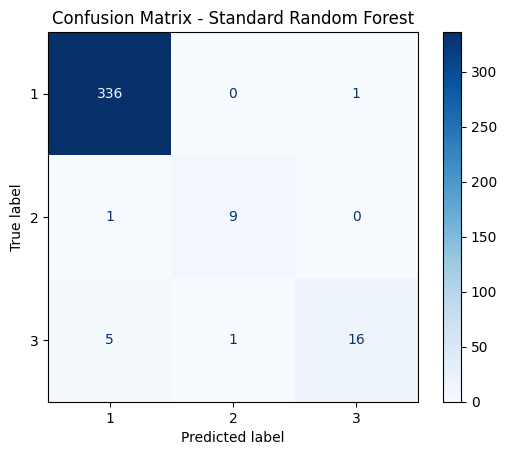

In [37]:
# Create a Random Forest Classifier with class weights
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,
    random_state=42
    #,class_weight='balanced'
)

# Train on original imbalanced data
rf_model.fit(X_train, y_train)  

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Calculate and print metrics
print("Standard Random Forest (with class weights) - Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Plot confusion matrix
plt.figure(figsize=(10, 8))
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_model.classes_)
disp_rf.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix - Standard Random Forest')
plt.show()

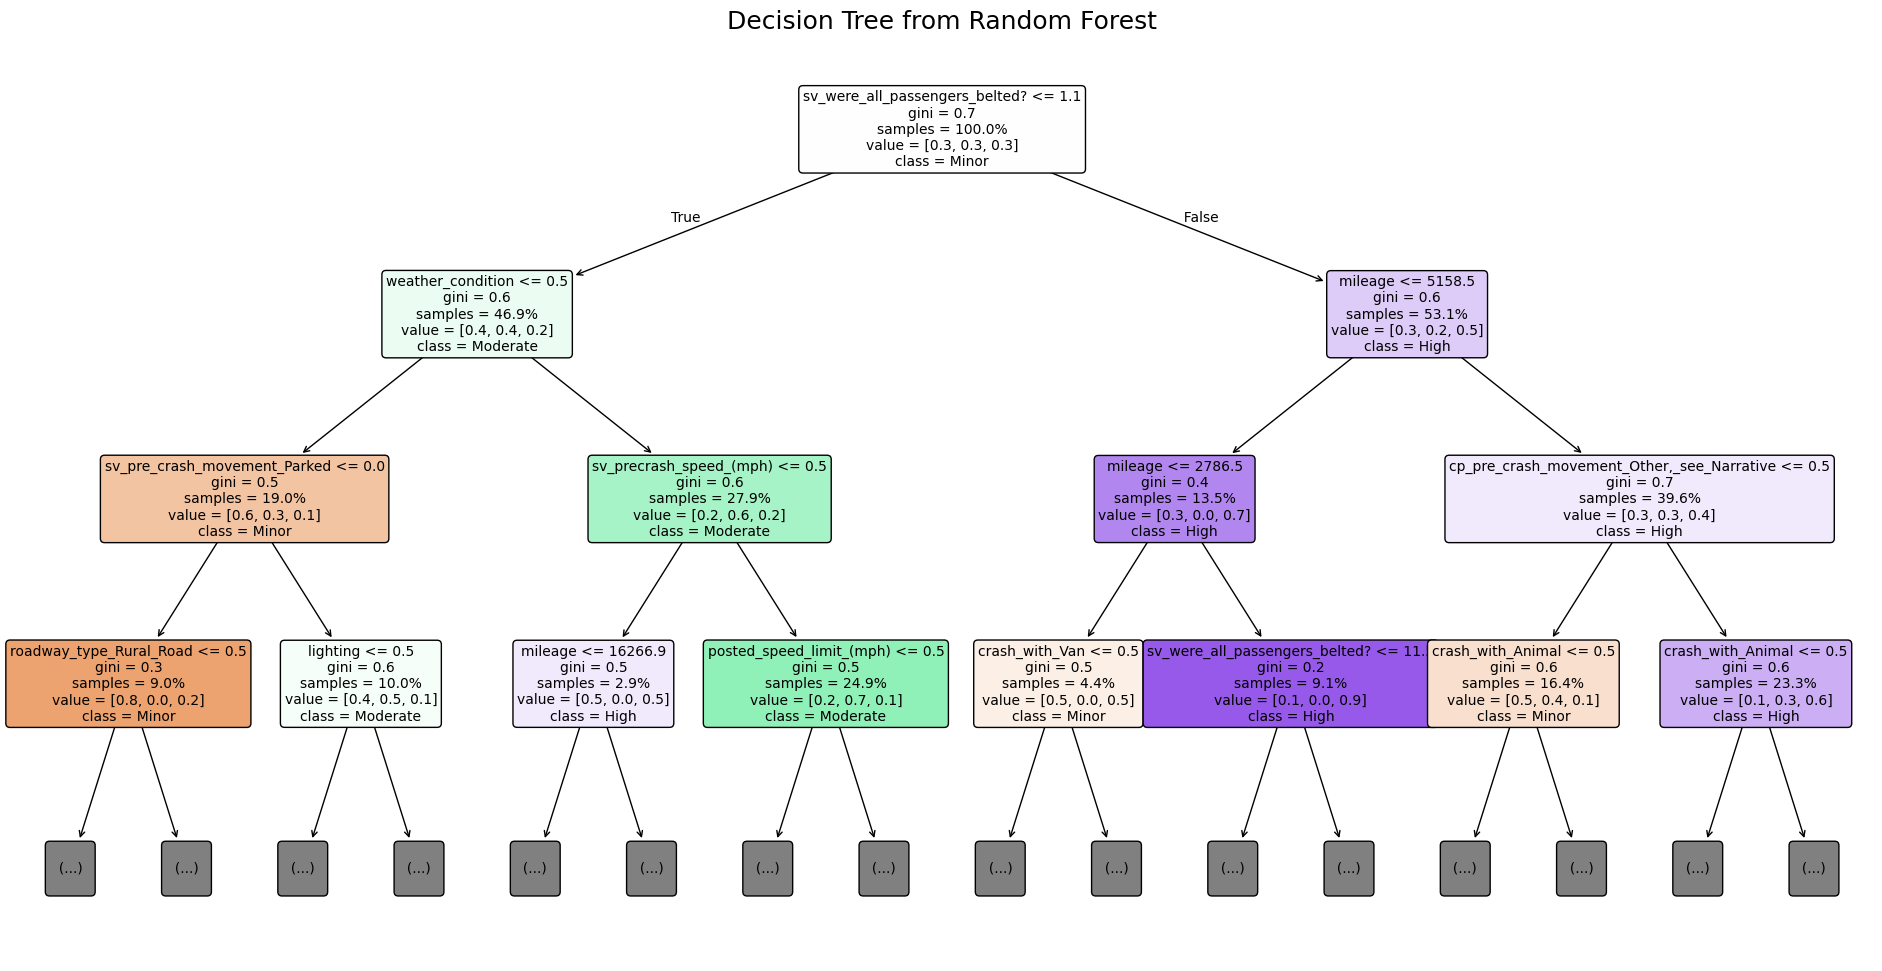

In [61]:
# Option 1: Enhanced standard tree plot with better formatting
plt.figure(figsize=(24, 12))
tree_plot = plot_tree(
    rf_model_robust.estimators_[10], 
    feature_names=X_train.columns, 
    class_names=['Minor', 'Moderate', 'High'],
    filled=True, 
    rounded=True, 
    max_depth=3,
    fontsize=10,
    proportion=True,  # Show proportions instead of counts
    precision=1
)
plt.title("Decision Tree from Random Forest", fontsize=18)
plt.savefig('enhanced_tree.png', dpi=300, bbox_inches='tight')
plt.show()


### Validating correlations

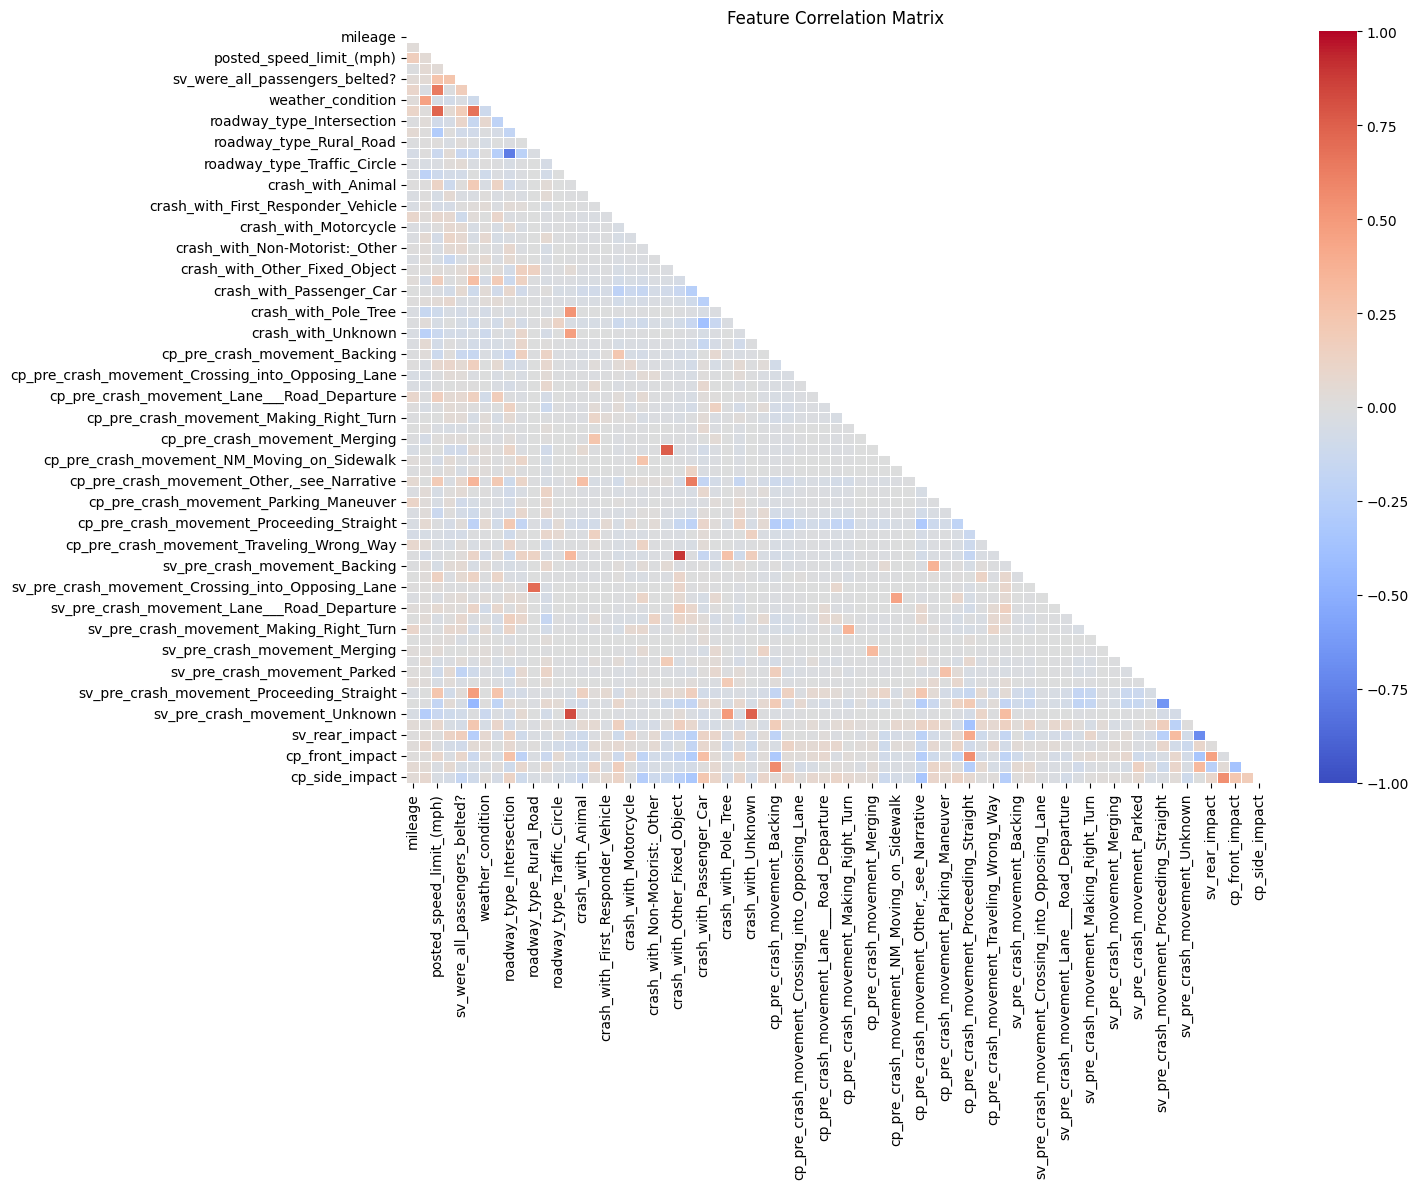

Highly correlated feature pairs:
roadway_type_Highway_Freeway and posted_speed_limit_(mph): 0.728
roadway_type_Street and roadway_type_Intersection: -0.777
cp_pre_crash_movement_NM_Crossing_Roadway and crash_with_Non-Motorist:_Pedestrian: 0.761
cp_pre_crash_movement_Unknown and crash_with_Other_Fixed_Object: 0.895
sv_pre_crash_movement_Crossing_into_Opposing_Lane and roadway_type_Rural_Road: 0.707
sv_pre_crash_movement_Unknown and roadway_type_Unknown: 0.824
sv_pre_crash_movement_Unknown and crash_with_Unknown: 0.744

Variance Inflation Factor (VIF) for numerical features:
                    Feature       VIF
1  posted_speed_limit_(mph)  8.295128
5            sv_side_impact  5.876346
8            cp_side_impact  4.867078
4            sv_rear_impact  4.486908
6           cp_front_impact  3.198558
3           sv_front_impact  2.712416
2   sv_precrash_speed_(mph)  2.466904
7            cp_rear_impact  1.670388
0                   mileage  1.403224


In [39]:
# For correlations between features
correlation_matrix = X_train.corr()

# Plot correlation heatmap
plt.figure(figsize=(15, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='coolwarm', 
            linewidths=0.5, vmax=1, vmin=-1)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Find highly correlated features
high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:  # Threshold for high correlation
            high_corr.append((correlation_matrix.columns[i], correlation_matrix.columns[j], 
                             correlation_matrix.iloc[i, j]))

print("Highly correlated feature pairs:")
for feat1, feat2, corr in high_corr:
    print(f"{feat1} and {feat2}: {corr:.3f}")

# For multicollinearity - Variance Inflation Factor (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select only numeric features
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
X_numeric = X_train[numeric_features]

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_numeric.columns
vif_data["VIF"] = [variance_inflation_factor(X_numeric.values, i) for i in range(X_numeric.shape[1])]

# Sort by VIF value
vif_data = vif_data.sort_values("VIF", ascending=False)
print("\nVariance Inflation Factor (VIF) for numerical features:")
print(vif_data.head(10))  # Top 10 features with highest VIF

### Validate overfitting

In [40]:
# Evaluate performance on training set
y_train_pred = rf_model.predict(X_train)
train_report = classification_report(y_train, y_train_pred, output_dict=True)

# Compare with test performance
y_test_pred = rf_model.predict(X_test)
test_report = classification_report(y_test, y_test_pred, output_dict=True)

# Create comparison table
comparison = pd.DataFrame({
    'Train F1-Score': [train_report['1']['f1-score'], train_report['2']['f1-score'], 
                       train_report['3']['f1-score'], train_report['macro avg']['f1-score']],
    'Test F1-Score': [test_report['1']['f1-score'], test_report['2']['f1-score'], 
                      test_report['3']['f1-score'], test_report['macro avg']['f1-score']]
}, index=['Class 1', 'Class 2', 'Class 3', 'Macro Avg'])

print("Training vs Test Performance Comparison:")
print(comparison)

# Cross-validation for more robust evaluation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='f1_macro')
print(f"\nCross-validation F1-macro scores: {cv_scores}")
print(f"Mean CV F1-macro score: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

Training vs Test Performance Comparison:
           Train F1-Score  Test F1-Score
Class 1          0.995562       0.989691
Class 2          0.962963       0.900000
Class 3          0.933333       0.820513
Macro Avg        0.963953       0.903401

Cross-validation F1-macro scores: [0.84289384 0.7841927  0.87496369 0.86317604 0.85229785]
Mean CV F1-macro score: 0.8435 (±0.0315)


### Validate results are valid

C:\Users\gabos\AppData\Local\Temp\ipykernel_2368\3027465866.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(perm_importance.importances[sorted_idx].T,


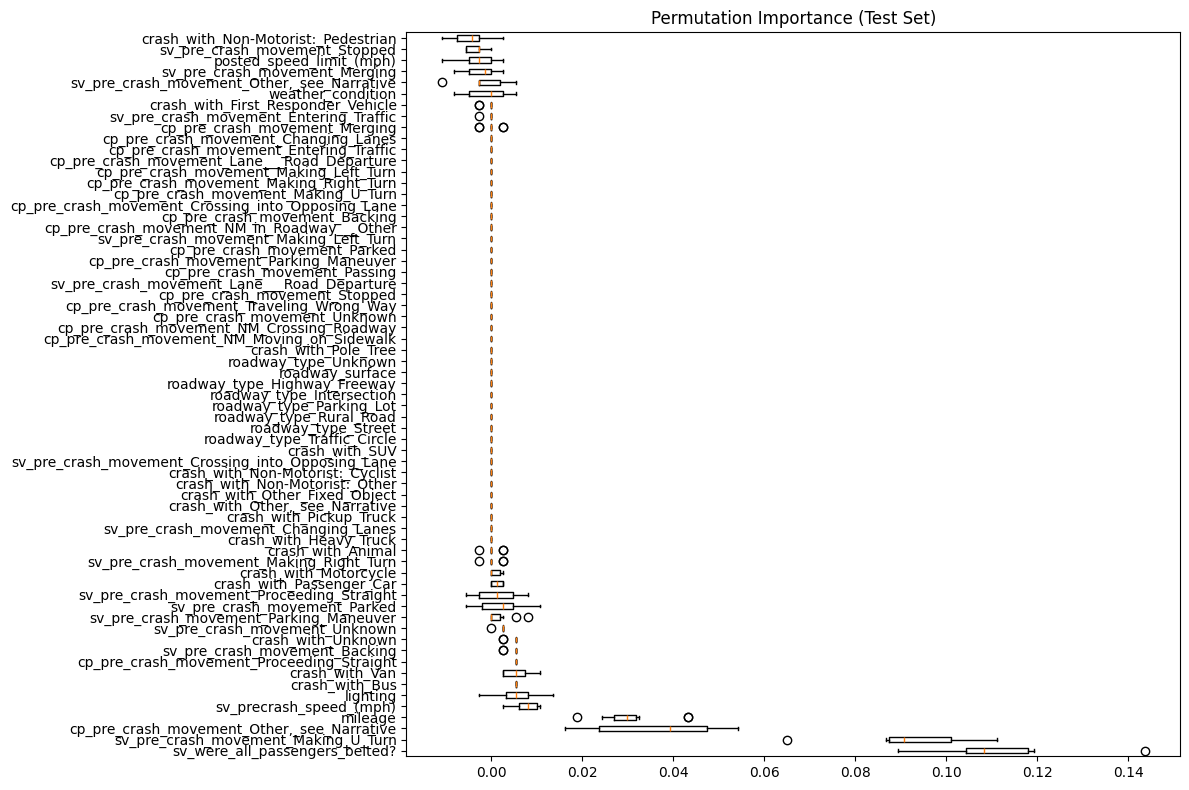

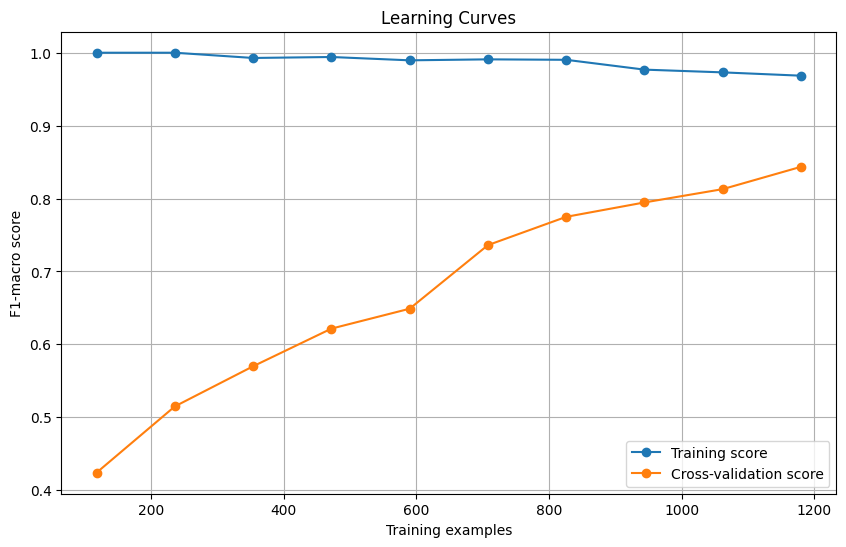

In [46]:
# Permutation importance - more reliable than default feature importance
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(rf_model_robust, X_test_enh, y_test_enh, 
                                       n_repeats=10, random_state=42)

sorted_idx = perm_importance.importances_mean.argsort()[::-1]
plt.figure(figsize=(12, 8))
plt.boxplot(perm_importance.importances[sorted_idx].T,
           vert=False, labels=[X_test.columns[i] for i in sorted_idx])
plt.title("Permutation Importance (Test Set)")
plt.tight_layout()
plt.show()

# Learning curves to assess if more data would help
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    rf_model, X_train, y_train, cv=5, scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Training score')
plt.plot(train_sizes, test_scores.mean(axis=1), 'o-', label='Cross-validation score')
plt.xlabel('Training examples')
plt.ylabel('F1-macro score')
plt.title('Learning Curves')
plt.legend(loc='best')
plt.grid()
plt.show()

### Addressing Overfitting

In [42]:
# 1. Modify Random Forest parameters to reduce overfitting
rf_model_robust = RandomForestClassifier(
    n_estimators=200,                # Keep a good number of trees
    max_depth=10,                    # Limit tree depth to prevent memorization
    min_samples_split=5,             # Require more samples to split a node
    min_samples_leaf=4,              # Require more samples in leaf nodes
    max_features=0.7,                # Use 70% of features for each split
    bootstrap=True,
    oob_score=True,                  # Use out-of-bag samples to estimate performance
    random_state=42,
    class_weight='balanced'          # Account for class imbalance
)

# 2. Implement cross-validation to get a reliable performance estimate
from sklearn.model_selection import cross_val_score, KFold

# Define cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
cv_scores = cross_val_score(rf_model_robust, X_train, y_train, 
                           cv=cv, scoring='f1_macro')

print(f"Cross-validation F1-macro scores: {cv_scores}")
print(f"Mean CV F1-macro score: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

# 3. Train final model on all training data
rf_model_robust.fit(X_train, y_train)

# 4. Evaluate on test set
y_pred_robust = rf_model_robust.predict(X_test)
print("Robust Random Forest - Classification Report:")
print(classification_report(y_test, y_pred_robust))

# 5. Check for overfitting by comparing OOB score with training score
print(f"Out-of-bag accuracy: {rf_model_robust.oob_score_:.4f}")

Cross-validation F1-macro scores: [0.83310364 0.8197335  0.77119242 0.84624205 0.77422159]
Mean CV F1-macro score: 0.8089 (±0.0307)
Robust Random Forest - Classification Report:
              precision    recall  f1-score   support

           1       0.98      0.98      0.98       337
           2       0.75      0.90      0.82        10
           3       0.70      0.64      0.67        22

    accuracy                           0.95       369
   macro avg       0.81      0.84      0.82       369
weighted avg       0.95      0.95      0.95       369

Out-of-bag accuracy: 0.9553


In [43]:
# 1. Identify and remove highly correlated features
def remove_multicollinear_features(X, correlation_threshold=0.7, vif_threshold=5):
    """
    Remove highly correlated features and those with high VIF
    
    Parameters:
    -----------
    X : pd.DataFrame
        The feature dataframe
    correlation_threshold : float
        The correlation threshold above which to remove features
    vif_threshold : float
        The VIF threshold above which to remove features
        
    Returns:
    --------
    pd.DataFrame
        The dataframe with multicollinear features removed
    """
    import numpy as np
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    
    # Step 1: Identify features with high pairwise correlation
    corr_matrix = X.corr().abs()
    
    # Extract the upper triangle of the correlation matrix
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Find features with correlation greater than threshold
    to_drop = [column for column in upper.columns if any(upper[column] > correlation_threshold)]
    
    print(f"Features to drop based on correlation > {correlation_threshold}:")
    for col in to_drop:
        # Find which features it's correlated with
        correlated_with = [
            f"{other_col} ({corr_matrix.loc[col, other_col]:.3f})"
            for other_col in corr_matrix.index
            if corr_matrix.loc[col, other_col] > correlation_threshold and col != other_col
        ]
        print(f"  - {col}: correlated with {', '.join(correlated_with)}")
    
    # Step 2: Calculate VIF for remaining features (if there are sufficient samples)
    if len(X) > len(X.columns):
        X_reduced = X.drop(columns=to_drop)
        
        # Only use numeric columns for VIF calculation
        numeric_cols = X_reduced.select_dtypes(include=['int64', 'float64']).columns
        
        if len(numeric_cols) > 1:  # Need at least 2 features for VIF
            # Calculate VIF
            vif_data = pd.DataFrame()
            vif_data["Feature"] = numeric_cols
            vif_data["VIF"] = [variance_inflation_factor(X_reduced[numeric_cols].values, i) 
                              for i in range(len(numeric_cols))]
            
            # Identify features with high VIF
            high_vif_features = vif_data[vif_data["VIF"] > vif_threshold]["Feature"].tolist()
            
            # Add high VIF features to the drop list
            for feature in high_vif_features:
                if feature not in to_drop:
                    to_drop.append(feature)
                    print(f"  - {feature}: high VIF ({vif_data[vif_data['Feature'] == feature]['VIF'].values[0]:.3f})")
    
    # Create a new dataframe without the identified features
    X_filtered = X.drop(columns=to_drop)
    print(f"Removed {len(to_drop)} features. Remaining features: {X_filtered.shape[1]}")
    
    return X_filtered, to_drop

# Apply the function to your features
X_filtered, dropped_features = remove_multicollinear_features(X, 
                                                             correlation_threshold=0.7, 
                                                             vif_threshold=5)

Features to drop based on correlation > 0.7:
  - roadway_type_Highway_Freeway: correlated with posted_speed_limit_(mph) (0.713)
  - roadway_type_Street: correlated with roadway_type_Intersection (0.769)
  - cp_pre_crash_movement_NM_Crossing_Roadway: correlated with crash_with_Non-Motorist:_Pedestrian (0.730)
  - cp_pre_crash_movement_Unknown: correlated with crash_with_Other_Fixed_Object (0.907)
  - sv_pre_crash_movement_Crossing_into_Opposing_Lane: correlated with roadway_type_Rural_Road (0.707)
  - sv_pre_crash_movement_Unknown: correlated with roadway_type_Unknown (0.803)
  - posted_speed_limit_(mph): high VIF (8.296)
  - sv_side_impact: high VIF (5.879)
Removed 8 features. Remaining features: 63


In [44]:
# Create meaningful interaction features
def add_interaction_features(X):
    """
    Add interaction features relevant to injury severity prediction
    
    Parameters:
    -----------
    X : pd.DataFrame
        The feature dataframe
        
    Returns:
    --------
    pd.DataFrame
        The dataframe with interaction features added
    """
    X_new = X.copy()
    
    # Speed and impact location interactions
    if 'posted_speed_limit_(mph)' in X.columns and 'sv_front_impact' in X.columns:
        X_new['speed_x_front_impact'] = X['posted_speed_limit_(mph)'] * X['sv_front_impact']
        print("Created: speed_x_front_impact")
    
    if 'posted_speed_limit_(mph)' in X.columns and 'sv_side_impact' in X.columns:
        X_new['speed_x_side_impact'] = X['posted_speed_limit_(mph)'] * X['sv_side_impact']
        print("Created: speed_x_side_impact")
    
    # Seatbelt usage and impact severity interactions
    if 'sv_were_all_passengers_belted?' in X.columns and 'sv_front_impact' in X.columns:
        X_new['belted_x_front_impact'] = X['sv_were_all_passengers_belted?'] * X['sv_front_impact']
        print("Created: belted_x_front_impact")
    
    # Road type and movement interactions
    if 'roadway_type_Intersection' in X.columns and 'sv_pre_crash_movement_Proceeding_Straight' in X.columns:
        X_new['intersection_x_proceeding_straight'] = X['roadway_type_Intersection'] * X['sv_pre_crash_movement_Proceeding_Straight']
        print("Created: intersection_x_proceeding_straight")
    
    # Lighting and road type interactions
    if 'lighting' in X.columns and 'roadway_type_Highway_Freeway' in X.columns:
        X_new['lighting_x_highway'] = X['lighting'] * X['roadway_type_Highway_Freeway']
        print("Created: lighting_x_highway")
    
    # Actual vs posted speed difference (potential risk indicator)
    if 'sv_precrash_speed_(mph)' in X.columns and 'posted_speed_limit_(mph)' in X.columns:
        X_new['speed_difference'] = X['sv_precrash_speed_(mph)'] - X['posted_speed_limit_(mph)']
        X_new['speed_ratio'] = X['sv_precrash_speed_(mph)'] / X['posted_speed_limit_(mph)'].replace(0, 1)  # Avoid division by zero
        print("Created: speed_difference and speed_ratio")
    
    print(f"Added {X_new.shape[1] - X.shape[1]} interaction features")
    return X_new

# Apply interaction features
X_enhanced = add_interaction_features(X_filtered)

Created: belted_x_front_impact
Created: intersection_x_proceeding_straight
Added 2 interaction features


### Enhanced Random Forest Pipeline with addressed overfitting

Features to drop based on correlation > 0.7:
  - roadway_type_Highway_Freeway: correlated with posted_speed_limit_(mph) (0.713)
  - roadway_type_Street: correlated with roadway_type_Intersection (0.769)
  - cp_pre_crash_movement_NM_Crossing_Roadway: correlated with crash_with_Non-Motorist:_Pedestrian (0.730)
  - cp_pre_crash_movement_Unknown: correlated with crash_with_Other_Fixed_Object (0.907)
  - sv_pre_crash_movement_Crossing_into_Opposing_Lane: correlated with roadway_type_Rural_Road (0.707)
  - sv_pre_crash_movement_Unknown: correlated with roadway_type_Unknown (0.803)
  - posted_speed_limit_(mph): high VIF (8.296)
  - sv_side_impact: high VIF (5.879)
Removed 8 features. Remaining features: 63
Created: belted_x_front_impact
Created: intersection_x_proceeding_straight
Added 2 interaction features

Enhanced Model - Classification Report:
              precision    recall  f1-score   support

           1       0.96      0.96      0.96       337
           2       0.56      0.90    

<Figure size 1000x800 with 0 Axes>

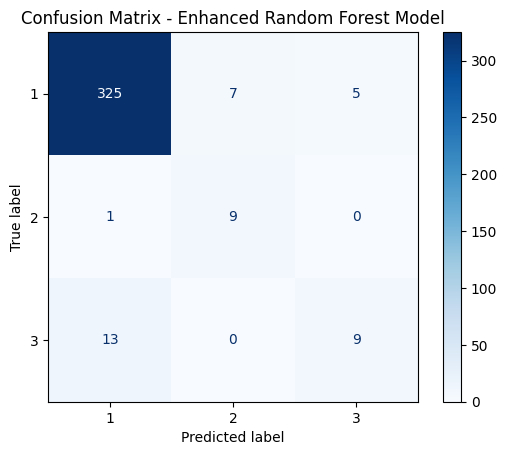

In [45]:
# Complete pipeline for addressing overfitting and multicollinearity
# 1. Remove multicollinear features
X_filtered, dropped_features = remove_multicollinear_features(X, 
                                                            correlation_threshold=0.7, 
                                                            vif_threshold=5)

# 2. Add interaction features
X_enhanced = add_interaction_features(X_filtered)

# 3. Split the enhanced dataset
X_train_enh, X_test_enh, y_train_enh, y_test_enh = train_test_split(
    X_enhanced, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Apply SMOTE to the training data
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_resampled_enh, y_resampled_enh = smote.fit_resample(X_train_enh, y_train_enh)

# 5. Create a more robust Random Forest model
rf_model_robust = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=4,
    max_features=0.7,
    bootstrap=True,
    oob_score=True,
    random_state=42,
    class_weight='balanced'
)

# 6. Train the model on the enhanced, resampled data
rf_model_robust.fit(X_resampled_enh, y_resampled_enh)

# 7. Evaluate on test set
y_pred_robust = rf_model_robust.predict(X_test_enh)
print("\nEnhanced Model - Classification Report:")
print(classification_report(y_test_enh, y_pred_robust))

# 8. Create confusion matrix for enhanced model
plt.figure(figsize=(10, 8))
cm_robust = confusion_matrix(y_test_enh, y_pred_robust)
disp_robust = ConfusionMatrixDisplay(confusion_matrix=cm_robust, display_labels=rf_model_robust.classes_)
disp_robust.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix - Enhanced Random Forest Model')
plt.show()

### Dtreeviz

In [ ]:
import dtreeviz
from dtreeviz.trees import dtreeviz


In [65]:
import dtreeviz
from dtreeviz.models import dtreeviz_sklearn

# Create visualization
viz = dtreeviz_sklearn(
    rf_model.estimators_[0],  # Select first tree
    X_train,                  # Training data
    y_train,                  # Target values
    feature_names=list(X_train.columns),
    class_names=["Minor", "Moderate", "Severe"],
    title="ADS Injury Severity Prediction Tree"
)

# Save the visualization
viz.save("tree_visualization.svg")

ImportError: cannot import name 'dtreeviz_sklearn' from 'dtreeviz.models' (c:\Users\gabos\AppData\Local\Programs\Python\Python310\lib\site-packages\dtreeviz\models\__init__.py)

### Shap Values

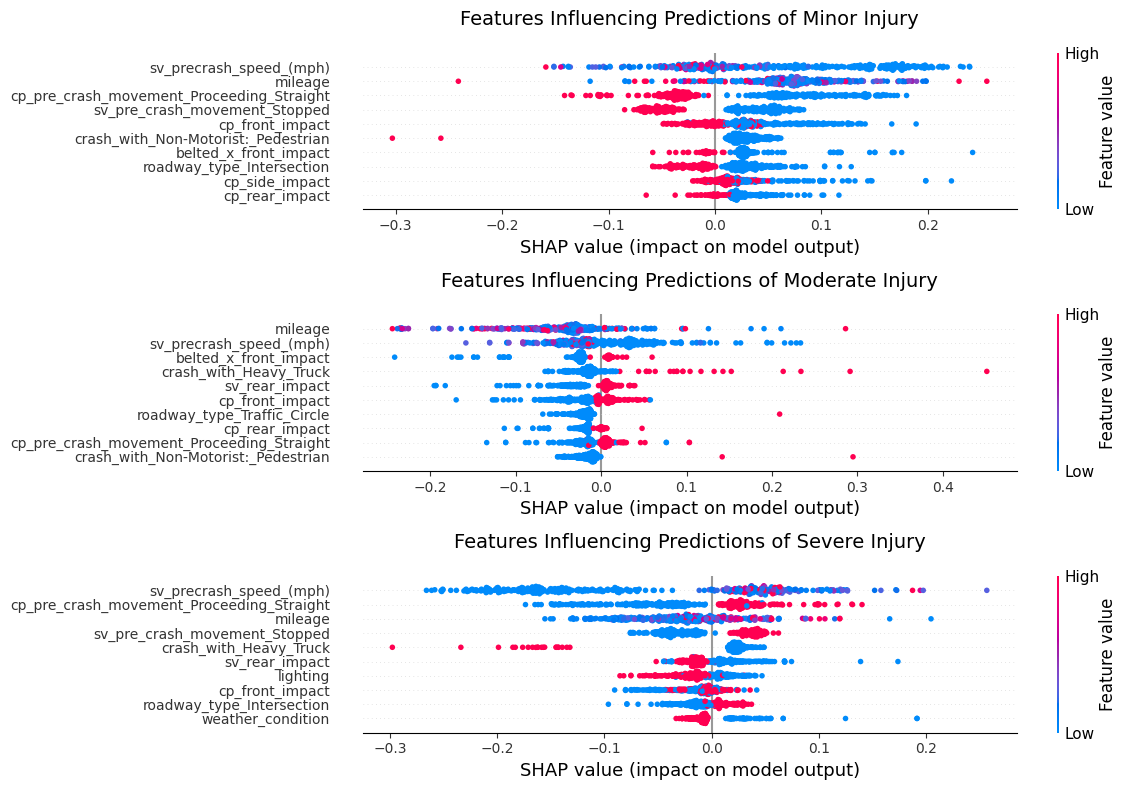

In [53]:
import shap
import matplotlib.pyplot as plt
import numpy as np

explainer = shap.TreeExplainer(rf_model_robust)
shap_values = explainer.shap_values(X_test_enh)
# Create a figure with subplots for all three classes, but with more height
fig, axes = plt.subplots(nrows=3, figsize=(14, 24))  # Increased height
class_names = ["Minor Injury", "Moderate Injury", "Severe Injury"]

# Create a summary plot for each class
for i in range(3):
    class_shap_values = shap_values[:, :, i]
    
    plt.sca(axes[i])  # Set the current axis
    
    # Key modification: increase max_display and adjust the plot size
    shap.summary_plot(
        class_shap_values,
        X_test_enh,
        feature_names=X_test_enh.columns.tolist(),
        show=False,  # Don't show yet to allow for customization
        max_display=10,  # Limit to top 15 features for readability
        plot_size=(12, 8)  # Control the aspect ratio
    )
    
    # Increase font size and adjust y-axis labels
    plt.yticks(fontsize=10)  # Adjust font size
    plt.xticks(fontsize=10)
    
    # Add more space for labels
    plt.tight_layout()
    
    # Set title with more padding
    plt.title(f"Features Influencing Predictions of {class_names[i]}", fontsize=14, pad=20)
    
    # Optional: Rotate y-axis labels for better readability
    ax = plt.gca()
    ax.tick_params(axis='y', labelrotation=0)

# Add spacing between subplots
plt.subplots_adjust(hspace=0.3)  # Increase vertical space between plots

plt.tight_layout()
plt.savefig('improved_shap_plots.png', dpi=300, bbox_inches='tight')
plt.show()

c:\Users\gabos\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\gabos\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\categorical.py:1273: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
c:\Users\gabos\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple 

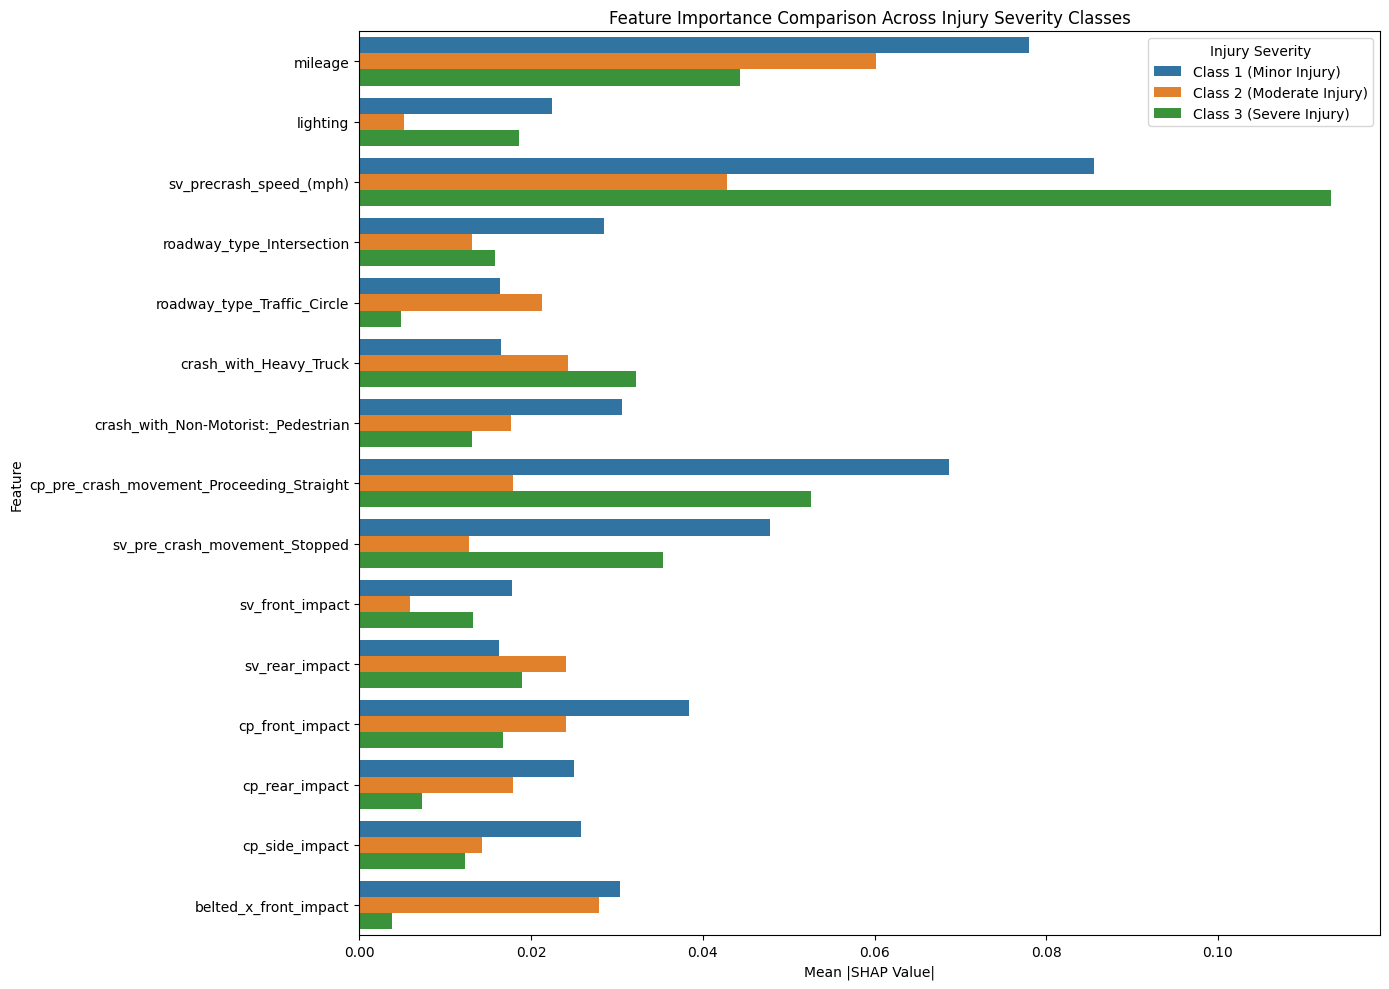

In [54]:
# Create a DataFrame to hold feature importance for each class
feature_importance_df = pd.DataFrame({'Feature': X_test_enh.columns})

# Add importance for each class
for i in range(3):
    class_shap_values = shap_values[:, :, i]
    mean_impact = np.abs(class_shap_values).mean(0)
    feature_importance_df[f'Class {i+1} ({class_names[i]})'] = mean_impact

# Identify the top 15 features overall
overall_importance = feature_importance_df.iloc[:, 1:].mean(axis=1)
feature_importance_df['Overall'] = overall_importance
top_features = feature_importance_df.sort_values('Overall', ascending=False).head(15)['Feature'].values

# Filter to only include top features and melt for plotting
plot_df = feature_importance_df[feature_importance_df['Feature'].isin(top_features)]
plot_df = pd.melt(plot_df, 
                  id_vars=['Feature'], 
                  value_vars=[f'Class {i+1} ({class_names[i]})' for i in range(3)],
                  var_name='Class', 
                  value_name='Importance')

# Create the comparison plot
plt.figure(figsize=(14, 10))
import seaborn as sns
sns.barplot(x='Importance', y='Feature', hue='Class', data=plot_df)
plt.title('Feature Importance Comparison Across Injury Severity Classes')
plt.xlabel('Mean |SHAP Value|')
plt.legend(title='Injury Severity')
plt.tight_layout()
plt.show()

### Text Processing (Narrative)

In [72]:

# Get 5 narrative examples for Severe injury
severe_examples = data[data['injury_severity_encoded'] == 2].sample(5)['narrative'].tolist()

# Get 5 narrative examples for Moderate injury
moderate_examples = data[data['injury_severity_encoded'] == 3].sample(5)['narrative'].tolist()

# Print the examples
print("Narrative Examples for Severe Injury:")
for example in severe_examples:
    print("- " + example)

print("\nNarrative Examples for Moderate Injury:")
for example in moderate_examples:
    print("- " + example)


Narrative Examples for Severe Injury:
- A Cruise autonomous vehicle ("AV"), operating in driverless autonomous mode, was at a complete stop in response to a red light on eastbound [XXX] at the intersection with [XXX]. As the AV was proceeding after the light turned green, a Dodge Charger traveling southbound on [XXX] failed to stop for the red light, entered the intersection, and made contact with the AV, damaging the front and rear driver side and rear bumper fascia of the AV. Police and Emergency Medical Services (EMS) were called to the scene. The AV was towed from the scene. The passenger of the Dodge Charger was assessed by medical personnel at the scene and was not transported by EMS. [REDACTED, MAY CONTAIN CONFIDENTIAL BUSINESS INFORMATION]
- There are no updates related to this incident since the original submission on August 27, 2023.  A Cruise autonomous vehicle ("AV"), operating in driverless autonomous mode, was at a complete stop in response to a red light on southbound [X

### First topic modeling (not final)

In [73]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Download NLTK resources if you haven't already
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

def basic_preprocess(text):
    """
    Basic preprocessing for narrative text
    """
    if not isinstance(text, str):
        return ""
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove special characters and digits (keep alphanumeric)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply preprocessing to narrative column
def preprocess_narratives(df, narrative_column='processed_narrative'):
    """
    Preprocess the narrative column in the dataframe
    """
    print(f"Preprocessing {len(df)} narratives...")
    
    # Create a copy to avoid modifying the original
    processed_df = df.copy()
    
    # Apply basic preprocessing
    processed_df['preprocessed_text'] = processed_df[narrative_column].apply(basic_preprocess)
    
    # Return the dataframe with the preprocessed column
    return processed_df

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\gabos\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gabos\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\gabos\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\gabos\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [74]:
def identify_tfidf_stopwords(preprocessed_texts, max_df=0.7, min_df=5, percentile_threshold=20):
    """
    Identify stopwords using TF-IDF scores
    
    Parameters:
    -----------
    preprocessed_texts : list or Series
        List of preprocessed text documents
    max_df : float, default=0.7
        Ignore terms that appear in more than this fraction of documents
    min_df : int, default=5
        Ignore terms that appear in fewer than this many documents
    percentile_threshold : int, default=20
        Percentile threshold for identifying stopwords (lower = more aggressive filtering)
    
    Returns:
    --------
    tfidf_stopwords : list
        List of identified stopwords
    vectorizer : TfidfVectorizer
        Fitted TF-IDF vectorizer
    """
    print(f"Calculating TF-IDF for {len(preprocessed_texts)} documents...")
    
    # Create TF-IDF vectorizer
    vectorizer = TfidfVectorizer(
        max_df=max_df,          # Ignore terms that appear in >max_df documents
        min_df=min_df,          # Ignore terms that appear in <min_df documents
        stop_words='english',   # Remove English stopwords
        lowercase=True,         # Convert to lowercase
        use_idf=True,           # Use inverse document frequency
        norm='l2',              # Normalize vectors
        smooth_idf=True,        # Smooth IDF weights
        sublinear_tf=True,      # Apply sublinear TF scaling (1 + log(TF))
        ngram_range=(1, 1)      # Use unigrams only (can be extended to bigrams if needed)
    )
    
    # Calculate TF-IDF matrix
    tfidf_matrix = vectorizer.fit_transform(preprocessed_texts)
    
    # Get feature names
    feature_names = vectorizer.get_feature_names_out()
    
    # Calculate average TF-IDF score for each term
    tfidf_means = tfidf_matrix.mean(axis=0).A1
    
    # Identify potential stopwords (terms with the lowest TF-IDF scores)
    threshold = np.percentile(tfidf_means, percentile_threshold)
    tfidf_stopwords = [feature_names[i] for i in np.where(tfidf_means <= threshold)[0]]
    
    print(f"Identified {len(tfidf_stopwords)} potential stopwords using TF-IDF")
    print(f"Examples: {tfidf_stopwords[:20]}")
    
    return tfidf_stopwords, vectorizer

In [75]:
def tokenize_with_tfidf_filtering(texts, tfidf_stopwords, custom_stopwords=None):
    """
    Tokenize and filter text using TF-IDF identified stopwords
    
    Parameters:
    -----------
    texts : list or Series
        List of preprocessed text documents
    tfidf_stopwords : list
        List of stopwords identified by TF-IDF
    custom_stopwords : list, optional
        Additional custom stopwords to remove
    
    Returns:
    --------
    processed_docs : list of list of str
        List of tokenized and filtered documents
    """
    print("Tokenizing and filtering documents...")
    
    # Initialize lemmatizer
    lemmatizer = WordNetLemmatizer()
    
    # Get standard English stopwords
    stop_words = set(stopwords.words('english'))
    
    # Add TF-IDF identified stopwords
    stop_words.update(tfidf_stopwords)
    
    # Add custom stopwords if provided
    if custom_stopwords:
        stop_words.update(custom_stopwords)
    
    # Process each document
    processed_docs = []
    
    for text in texts:
        if not isinstance(text, str) or len(text.strip()) == 0:
            processed_docs.append([])
            continue
        
        # Tokenize
        tokens = word_tokenize(text)
        
        # Filter and lemmatize
        filtered_tokens = [
            lemmatizer.lemmatize(word) for word in tokens
            if word.isalpha() and word not in stop_words and len(word) > 2
        ]
        
        processed_docs.append(filtered_tokens)
    
    return processed_docs

In [76]:
def get_domain_stopwords():
    """
    Create domain-specific stopwords for accident narratives
    """
    domain_stopwords = [
        # Common accident report terminology
        'vehicle', 'car', 'driver', 'passenger', 'road', 'crash', 'accident', 
        'injury', 'report', 'police', 'occurred', 'scene', 'involved',
        
        # Administrative language
        'submission', 'order', 'reference', 'field', 'response', 'based',
        'fact', 'general', 'llc', 'reporting', 'submitted', 'sustained',
        'incident', 'motor', 'information', 'operating',
        
        # Common verbs with low information value
        'stated', 'reported', 'called', 'contacted', 'received', 'sustained',
        
        # Company names that appear frequently
        'cruise', 'waymo', 'zoox', 'autonomous', 'autonomy',
        
        # Time-related terms
        'time', 'day', 'date', 'minute', 'second', 'hour',
        
        # Directional/spatial terms that are too common
        'left', 'right', 'front', 'rear', 'side', 'top', 'bottom',
        
        # Additional terms that might be too general
        'may', 'update', 'engaged', 'lane', 'mode'
    ]
    
    return domain_stopwords

In [77]:
def apply_tfidf_preprocessing(data, narrative_column='processed_narrative', max_df=0.7, 
                             min_df=5, percentile_threshold=20):
    """
    Complete pipeline for TF-IDF based preprocessing of narrative text
    
    Parameters:
    -----------
    data : pandas DataFrame
        DataFrame containing narrative column
    narrative_column : str, default='processed_narrative'
        Name of the column containing narrative text
    max_df : float, default=0.7
        Ignore terms that appear in more than this fraction of documents
    min_df : int, default=5
        Ignore terms that appear in fewer than this many documents
    percentile_threshold : int, default=20
        Percentile threshold for identifying stopwords
    
    Returns:
    --------
    processed_docs : list of list of str
        List of tokenized and filtered documents
    tfidf_stopwords : list
        List of stopwords identified by TF-IDF
    """
    # Step 1: Basic preprocessing
    processed_df = preprocess_narratives(data, narrative_column)
    
    # Step 2: Calculate TF-IDF and identify stopwords
    tfidf_stopwords, vectorizer = identify_tfidf_stopwords(
        processed_df['preprocessed_text'],
        max_df=max_df,
        min_df=min_df,
        percentile_threshold=percentile_threshold
    )
    
    # Step 3: Get domain-specific stopwords
    domain_stopwords = get_domain_stopwords()
    
    # Step 4: Tokenize and filter using TF-IDF stopwords and domain-specific stopwords
    processed_docs = tokenize_with_tfidf_filtering(
        processed_df['preprocessed_text'],
        tfidf_stopwords,
        custom_stopwords=domain_stopwords
    )
    
    # Step 5: Analyze the results
    token_counts = [len(doc) for doc in processed_docs]
    print(f"Average tokens per document after filtering: {np.mean(token_counts):.1f}")
    print(f"Documents with no tokens after filtering: {sum(count == 0 for count in token_counts)}")
    
    # Return the processed documents and stopwords
    return processed_docs, tfidf_stopwords

In [78]:
def visualize_tfidf_impact(tfidf_vectorizer, tfidf_stopwords, top_n=30):
    """
    Visualize the impact of TF-IDF filtering
    
    Parameters:
    -----------
    tfidf_vectorizer : TfidfVectorizer
        Fitted TF-IDF vectorizer
    tfidf_stopwords : list
        List of stopwords identified by TF-IDF
    top_n : int, default=30
        Number of top and bottom terms to show
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Get all feature names
    feature_names = tfidf_vectorizer.get_feature_names_out()
    
    # Get the IDF values
    idf_values = tfidf_vectorizer.idf_
    
    # Create a dataframe with terms and their IDF values
    idf_df = pd.DataFrame({
        'term': feature_names,
        'idf': idf_values
    })
    
    # Sort by IDF values
    idf_df = idf_df.sort_values('idf')
    
    # Identify terms that were removed as stopwords
    idf_df['is_stopword'] = idf_df['term'].isin(tfidf_stopwords)
    
    # Plot the top and bottom N terms by IDF
    plt.figure(figsize=(12, 10))
    
    # Plot terms with lowest IDF (most common)
    plt.subplot(2, 1, 1)
    sns.barplot(x='term', y='idf', hue='is_stopword', data=idf_df.head(top_n))
    plt.title(f'Top {top_n} Most Common Terms (Lowest IDF)')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Removed as stopword')
    
    # Plot terms with highest IDF (most distinctive)
    plt.subplot(2, 1, 2)
    sns.barplot(x='term', y='idf', data=idf_df.tail(top_n))
    plt.title(f'Top {top_n} Most Distinctive Terms (Highest IDF)')
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.savefig('tfidf_analysis.png', dpi=300)
    plt.show()

In [79]:
# Apply TF-IDF preprocessing to your data
processed_docs, tfidf_stopwords = apply_tfidf_preprocessing(
    data,                          # Your DataFrame
    narrative_column='processed_narrative',  # Your narrative column
    max_df=0.7,                    # Ignore terms in >70% of documents
    min_df=5,                      # Ignore terms in <5 documents
    percentile_threshold=20        # Consider bottom 20% of TF-IDF scores as stopwords
)

# Now you can use processed_docs for your topic modeling

# Import gensim for topic modeling
import gensim
import gensim.corpora as corpora

# Create dictionary
id2word = corpora.Dictionary(processed_docs)

# Create corpus
corpus = [id2word.doc2bow(text) for text in processed_docs]

# Build LDA model
lda_model = gensim.models.LdaMulticore(
    corpus=corpus,
    id2word=id2word,
    num_topics=10,       # Adjust based on your needs
    passes=10,
    workers=4,
    random_state=42
)

# Print the topics
for idx, topic in lda_model.print_topics():
    print(f'Topic {idx}: {topic}')

Preprocessing 1844 narratives...
Calculating TF-IDF for 1844 documents...
Identified 215 potential stopwords using TF-IDF
Examples: ['abundance', 'acceleration', 'accommodate', 'accordingly', 'active', 'actual', 'adaptive', 'address', 'advised', 'ae', 'aggressively', 'allegedly', 'america', 'angle', 'arrive', 'asked', 'assumed', 'ave', 'aways', 'base']
Tokenizing and filtering documents...
Average tokens per document after filtering: 43.9
Documents with no tokens after filtering: 0
Topic 0: 0.043*"fact" + 0.043*"field" + 0.042*"response" + 0.023*"alleged" + 0.022*"currently" + 0.022*"entity" + 0.022*"also" + 0.022*"knowledge" + 0.022*"incorporates" + 0.022*"independent"
Topic 1: 0.021*"bicyclist" + 0.015*"stop" + 0.013*"fire" + 0.011*"please" + 0.010*"intersection" + 0.010*"delivery" + 0.010*"engine" + 0.009*"injury" + 0.009*"level" + 0.008*"sign"
Topic 2: 0.038*"motorcycle" + 0.036*"operator" + 0.035*"aurora" + 0.023*"truck" + 0.016*"pedestrian" + 0.016*"motorcyclist" + 0.015*"disenga

### Topic modeling functions

In [80]:
import pyLDAvis
import pyLDAvis.gensim_models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gensim.models import CoherenceModel

def create_lda_visualization(lda_model, corpus, dictionary):
    """
    Create an interactive visualization of your LDA model
    """
    # Prepare the visualization
    vis_data = pyLDAvis.gensim_models.prepare(
        lda_model, 
        corpus, 
        dictionary,
        mds='tsne',  # Use t-SNE for the projection (better than default PCA)
        sort_topics=False  # Keep the original topic order
    )
    
    # Display the visualization in Jupyter notebook
    pyLDAvis.display(vis_data)
    
    # Save to HTML file (can be shared or opened in a browser)
    pyLDAvis.save_html(vis_data, 'lda_visualization.html')
    
    print("Interactive visualization saved to 'lda_visualization.html'")
    return vis_data

In [81]:
def find_optimal_number_of_topics(corpus, dictionary, processed_docs, start=2, limit=20, step=1):
    """
    Find the optimal number of topics by computing coherence scores
    for different numbers of topics
    """
    from gensim.models import LdaMulticore
    
    coherence_values = []
    model_list = []
    
    for num_topics in range(start, limit, step):
        # Create and train the model
        model = LdaMulticore(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            passes=15,
            workers=4,
            random_state=42
        )
        
        model_list.append(model)
        
        # Calculate coherence score
        coherence_model = CoherenceModel(
            model=model,
            texts=processed_docs,
            dictionary=dictionary,
            coherence='c_v'  # Use c_v coherence (best semantic measure)
        )
        
        coherence_score = coherence_model.get_coherence()
        coherence_values.append(coherence_score)
        
        print(f"Num Topics: {num_topics}, Coherence Score: {coherence_score:.4f}")
    
    # Plot the coherence scores
    plt.figure(figsize=(12, 6))
    plt.plot(range(start, limit, step), coherence_values, marker='o')
    plt.xlabel("Number of Topics")
    plt.ylabel("Coherence Score (higher is better)")
    plt.title("Optimal Number of Topics by Coherence Score")
    plt.xticks(range(start, limit, step))
    plt.grid(True)
    plt.savefig('topic_coherence_scores.png', dpi=300)
    plt.show()
    
    # Find the model with the highest coherence score
    optimal_idx = coherence_values.index(max(coherence_values))
    optimal_model = model_list[optimal_idx]
    optimal_topics = range(start, limit, step)[optimal_idx]
    
    print(f"Optimal number of topics: {optimal_topics} with coherence score: {max(coherence_values):.4f}")
    
    return optimal_model, coherence_values

In [82]:
def visualize_and_interpret_topics(lda_model, corpus, dictionary, processed_docs, top_n_words=15):
    """
    Create visualizations to help interpret topics
    """
    import seaborn as sns
    from wordcloud import WordCloud
    
    # 1. Get the top words for each topic
    topics_words = {}
    for t in range(lda_model.num_topics):
        words = lda_model.show_topic(t, topn=top_n_words)
        topics_words[t] = [(word, round(prob, 3)) for word, prob in words]
    
    # 2. Create word clouds for each topic
    fig, axes = plt.subplots(int(np.ceil(lda_model.num_topics/2)), 2, 
                           figsize=(15, 3*np.ceil(lda_model.num_topics/2)))
    axes = axes.flatten()
    
    for i, ax in enumerate(axes):
        if i < lda_model.num_topics:
            fig.add_subplot(ax)
            topic_words = dict(topics_words[i])
            wordcloud = WordCloud(background_color='white', width=600, height=400,
                                max_font_size=100, random_state=42)
            wordcloud.generate_from_frequencies(topic_words)
            ax.imshow(wordcloud)
            ax.set_title(f'Topic {i+1}')
            ax.axis('off')
    
    plt.tight_layout()
    plt.savefig('topic_word_clouds.png', dpi=300)
    plt.show()
    
    # 3. Create bar chart of top terms for each topic
    for t in range(lda_model.num_topics):
        words, probs = zip(*topics_words[t])
        plt.figure(figsize=(10, 4))
        plt.barh(range(len(words)), probs, align='center')
        plt.yticks(range(len(words)), words)
        plt.title(f'Top {top_n_words} Words for Topic {t+1}')
        plt.xlabel('Probability')
        plt.tight_layout()
        plt.savefig(f'topic_{t+1}_words.png', dpi=300)
        plt.show()
    
    # 4. Calculate topic distribution across documents
    doc_topics = []
    for doc in corpus:
        topic_probs = lda_model.get_document_topics(doc)
        doc_topics.append(topic_probs)
    
    # Create a matrix of document-topic distribution
    doc_topic_matrix = np.zeros((len(corpus), lda_model.num_topics))
    for i, doc_topic in enumerate(doc_topics):
        for topic, prob in doc_topic:
            doc_topic_matrix[i, topic] = prob
    
    # 5. Average topic distribution
    avg_topic_distribution = doc_topic_matrix.mean(axis=0)
    plt.figure(figsize=(10, 6))
    plt.bar(range(1, lda_model.num_topics + 1), avg_topic_distribution)
    plt.xlabel('Topic')
    plt.ylabel('Average Weight')
    plt.title('Average Topic Distribution Across Documents')
    plt.xticks(range(1, lda_model.num_topics + 1))
    plt.grid(axis='y')
    plt.savefig('average_topic_distribution.png', dpi=300)
    plt.show()
    
    # 6. Topic correlation heatmap
    topic_correlation = np.corrcoef(doc_topic_matrix.T)
    plt.figure(figsize=(10, 8))
    sns.heatmap(topic_correlation, annot=True, cmap='coolwarm', 
               xticklabels=range(1, lda_model.num_topics + 1),
               yticklabels=range(1, lda_model.num_topics + 1))
    plt.title('Topic Correlation Matrix')
    plt.savefig('topic_correlation.png', dpi=300)
    plt.show()
    
    # 7. Print topic interpretations
    print("\nTopic Interpretations:")
    for t in range(lda_model.num_topics):
        print(f"\nTopic {t+1}:")
        print(f"Weight in corpus: {avg_topic_distribution[t]:.3f}")
        print("Top words: " + ", ".join([word for word, _ in topics_words[t][:7]]))
        print("Suggested interpretation: A topic about...")
        
    return doc_topic_matrix

In [83]:
def run_complete_lda_analysis(processed_docs, find_optimal=True, num_topics=10, 
                             coherence_start=2, coherence_limit=20, coherence_step=2):
    """
    Complete LDA topic modeling workflow that:
    1. Creates the dictionary and corpus
    2. Finds the optimal number of topics (if requested)
    3. Builds the LDA model
    4. Creates visualizations and interpretations
    
    Parameters:
    -----------
    processed_docs : list of list of str
        List of tokenized documents from TF-IDF preprocessing
    find_optimal : bool, default=True
        Whether to find the optimal number of topics
    num_topics : int, default=10
        Number of topics (used if find_optimal=False)
    coherence_start, coherence_limit, coherence_step : int
        Parameters for topic number search
    
    Returns:
    --------
    lda_model, corpus, dictionary, doc_topic_matrix
    """
    import gensim.corpora as corpora
    from gensim.models import LdaMulticore
    
    # Create Dictionary
    dictionary = corpora.Dictionary(processed_docs)
    
    # Filter extremes for better results
    dictionary.filter_extremes(no_below=5, no_above=0.7)
    
    # Create Corpus
    corpus = [dictionary.doc2bow(doc) for doc in processed_docs]
    
    # Find optimal number of topics if requested
    if find_optimal:
        print("Finding optimal number of topics...")
        lda_model, coherence_values = find_optimal_number_of_topics(
            corpus, dictionary, processed_docs,
            start=coherence_start, limit=coherence_limit, step=coherence_step
        )
        num_topics = lda_model.num_topics
    else:
        # Build LDA model with specified number of topics
        print(f"Building LDA model with {num_topics} topics...")
        lda_model = LdaMulticore(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            passes=15,
            workers=4,
            random_state=42
        )
    
    # Print topic keywords
    print("\nTopic Keywords:")
    for idx, topic in lda_model.print_topics(num_words=10):
        print(f'Topic {idx+1}: {topic}')
    
    # Create interactive visualization
    print("\nCreating interactive visualization...")
    vis_data = create_lda_visualization(lda_model, corpus, dictionary)
    
    # Visualize and interpret topics
    print("\nVisualizing and interpreting topics...")
    doc_topic_matrix = visualize_and_interpret_topics(lda_model, corpus, dictionary, processed_docs)
    
    # Return the model and related data
    return lda_model, corpus, dictionary, doc_topic_matrix

### Processing Topics

Preprocessing 1844 narratives...
Calculating TF-IDF for 1844 documents...
Identified 215 potential stopwords using TF-IDF
Examples: ['abundance', 'acceleration', 'accommodate', 'accordingly', 'active', 'actual', 'adaptive', 'address', 'advised', 'ae', 'aggressively', 'allegedly', 'america', 'angle', 'arrive', 'asked', 'assumed', 'ave', 'aways', 'base']
Tokenizing and filtering documents...
Average tokens per document after filtering: 43.9
Documents with no tokens after filtering: 0
Finding optimal number of topics...
Num Topics: 2, Coherence Score: 0.6435
Num Topics: 4, Coherence Score: 0.6994
Num Topics: 6, Coherence Score: 0.7610
Num Topics: 8, Coherence Score: 0.6872
Num Topics: 10, Coherence Score: 0.6878
Num Topics: 12, Coherence Score: 0.6906
Num Topics: 14, Coherence Score: 0.6449
Num Topics: 16, Coherence Score: 0.6377
Num Topics: 18, Coherence Score: 0.6173


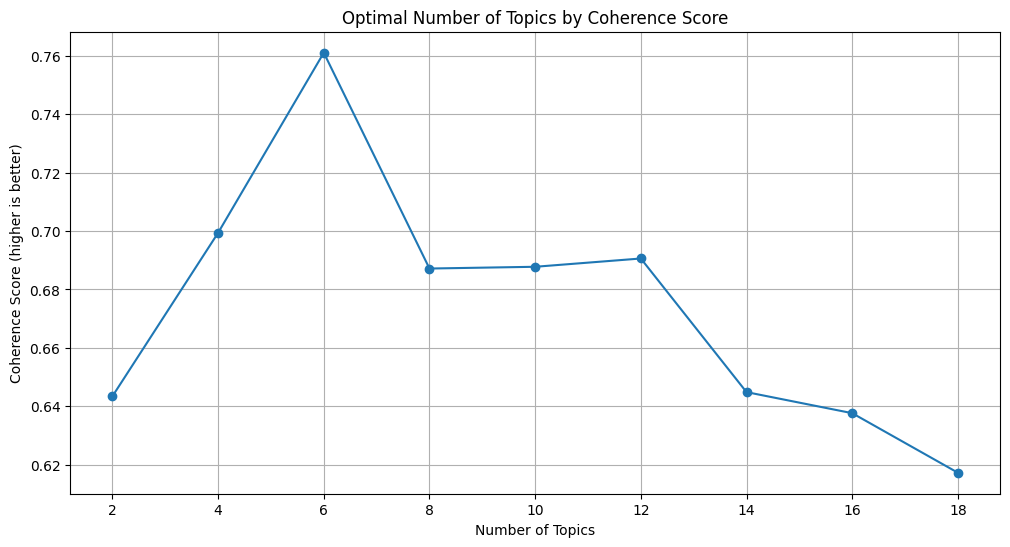

Optimal number of topics: 6 with coherence score: 0.7610

Topic Keywords:
Topic 1: 0.110*"truck" + 0.046*"pickup" + 0.024*"trailer" + 0.014*"traveling" + 0.013*"semi" + 0.012*"turn" + 0.011*"kodiak" + 0.009*"impact" + 0.009*"manual" + 0.009*"test"
Topic 2: 0.042*"fact" + 0.042*"field" + 0.041*"response" + 0.024*"redacted" + 0.022*"alleged" + 0.022*"knowledge" + 0.021*"entity" + 0.021*"version" + 0.021*"submitting" + 0.021*"also"
Topic 3: 0.028*"correct" + 0.027*"standing" + 0.027*"request" + 0.027*"involving" + 0.027*"supplement" + 0.026*"impact" + 0.026*"become" + 0.026*"additional" + 0.026*"available" + 0.026*"level"
Topic 4: 0.030*"intersection" + 0.024*"stopped" + 0.023*"traveling" + 0.022*"traffic" + 0.022*"light" + 0.021*"made" + 0.020*"ad" + 0.019*"stop" + 0.018*"impact" + 0.018*"standing"
Topic 5: 0.027*"traveling" + 0.024*"confidential" + 0.024*"business" + 0.024*"redacted" + 0.023*"injury" + 0.022*"contain" + 0.022*"intersection" + 0.019*"stop" + 0.018*"operator" + 0.017*"mad

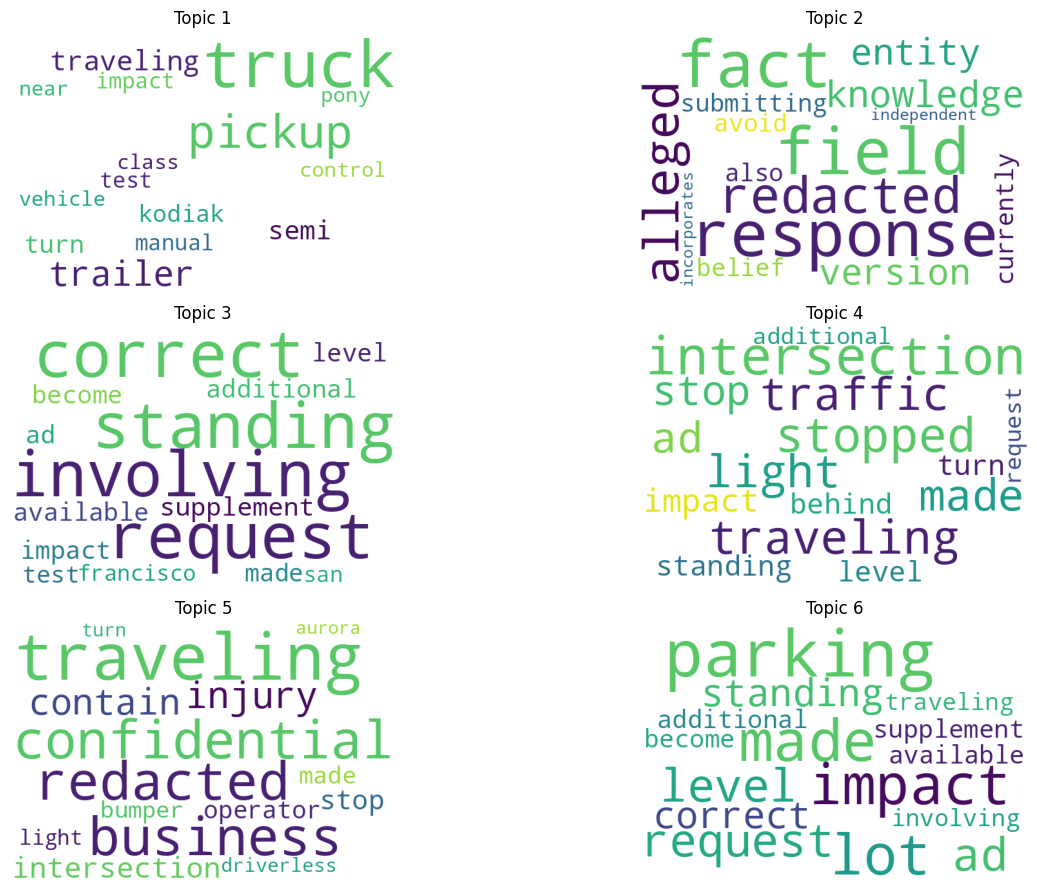

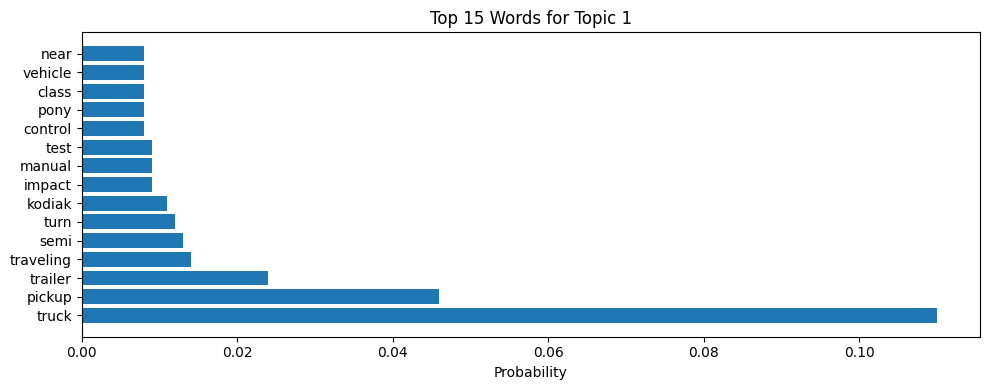

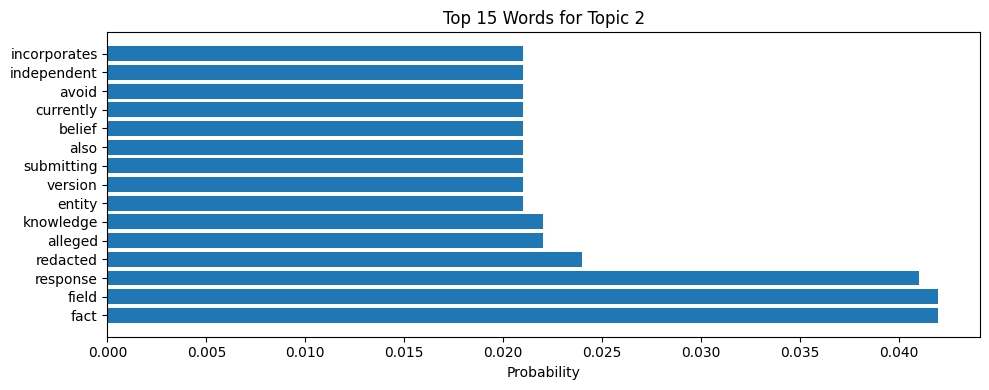

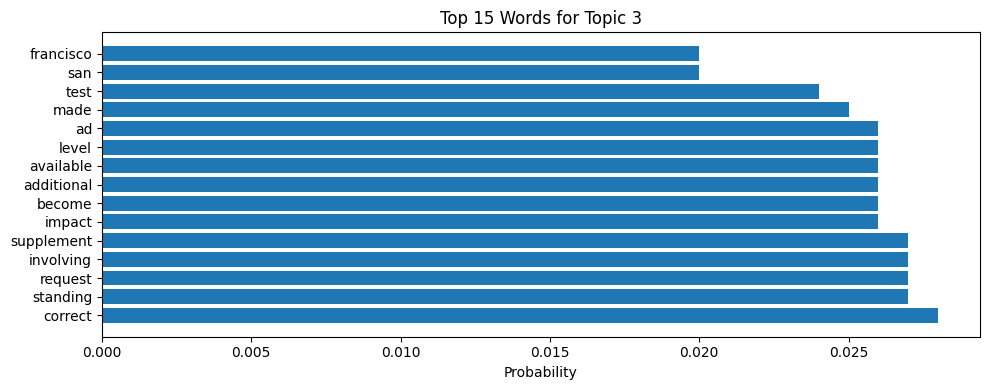

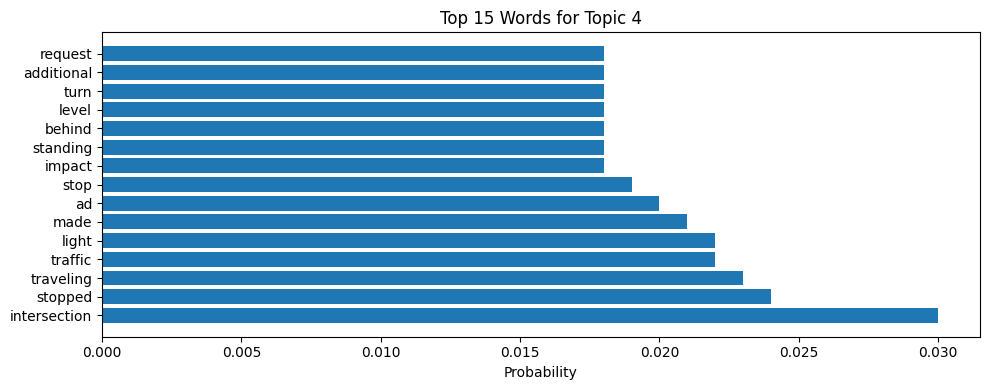

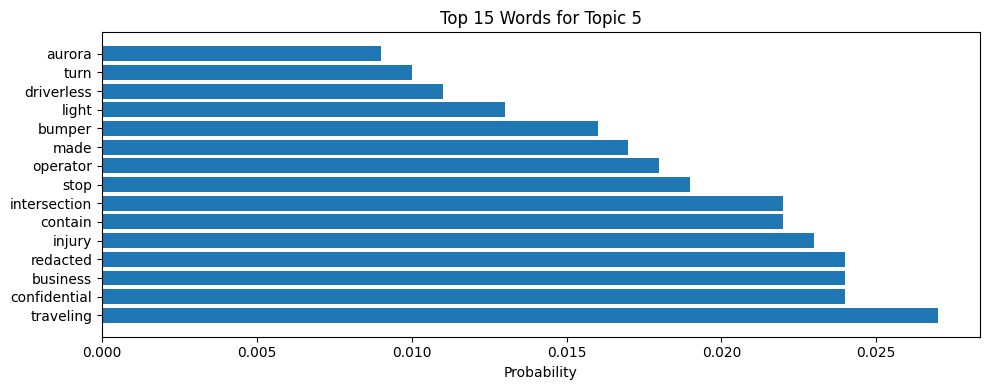

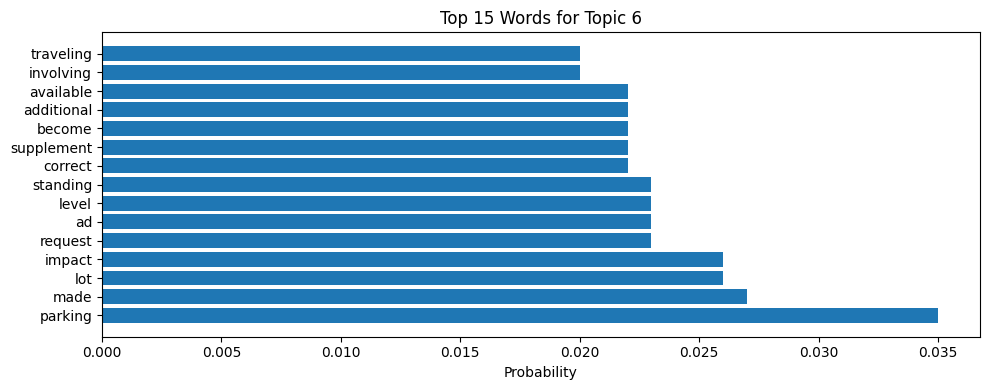

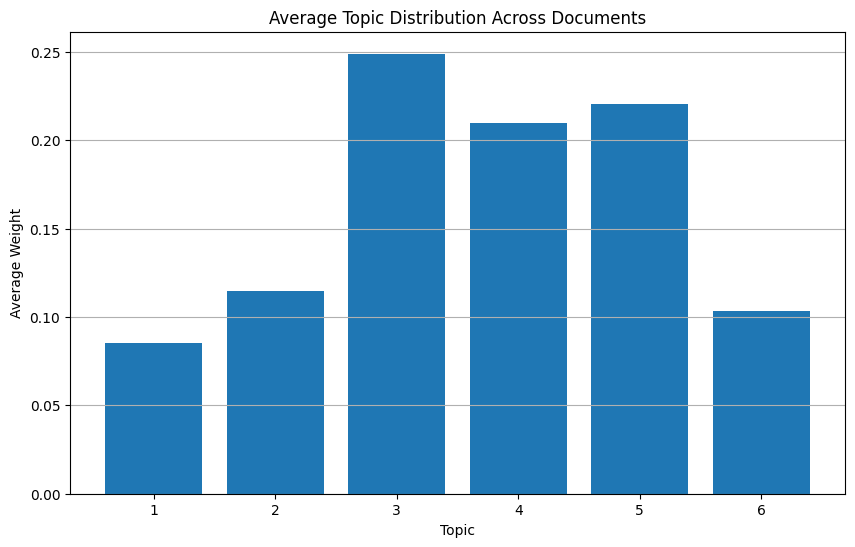

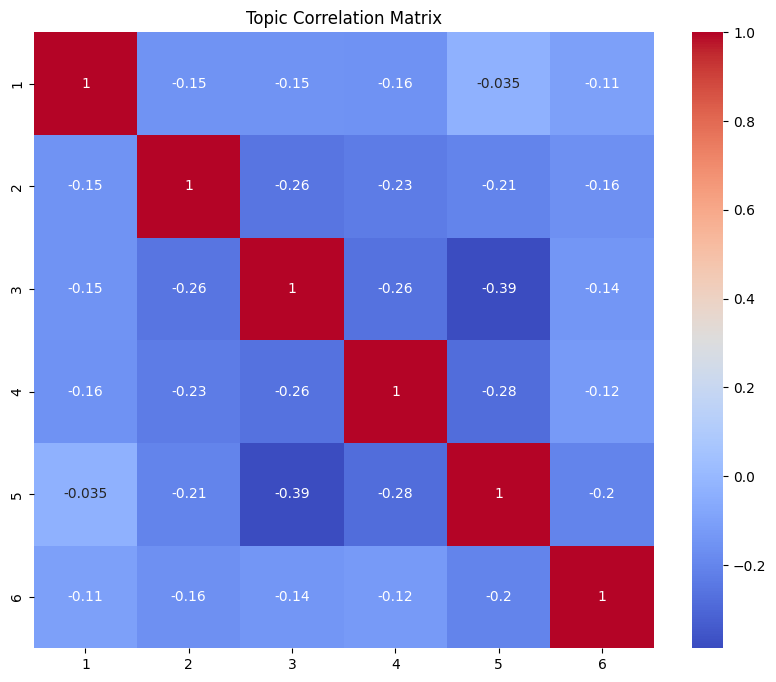


Topic Interpretations:

Topic 1:
Weight in corpus: 0.085
Top words: truck, pickup, trailer, traveling, semi, turn, kodiak
Suggested interpretation: A topic about...

Topic 2:
Weight in corpus: 0.115
Top words: fact, field, response, redacted, alleged, knowledge, entity
Suggested interpretation: A topic about...

Topic 3:
Weight in corpus: 0.249
Top words: correct, standing, request, involving, supplement, impact, become
Suggested interpretation: A topic about...

Topic 4:
Weight in corpus: 0.210
Top words: intersection, stopped, traveling, traffic, light, made, ad
Suggested interpretation: A topic about...

Topic 5:
Weight in corpus: 0.221
Top words: traveling, confidential, business, redacted, injury, contain, intersection
Suggested interpretation: A topic about...

Topic 6:
Weight in corpus: 0.103
Top words: parking, made, lot, impact, request, ad, level
Suggested interpretation: A topic about...


In [84]:
# First, use your TF-IDF preprocessing to get processed documents
processed_docs, tfidf_stopwords = apply_tfidf_preprocessing(
    data, 
    narrative_column='processed_narrative'
)

# Then run the complete LDA analysis
lda_model, corpus, dictionary, doc_topics = run_complete_lda_analysis(
    processed_docs,
    find_optimal=True,
    coherence_start=2,
    coherence_limit=20,
    coherence_step=2
)

In [159]:
import pickle

# 1. Save your Random Forest model
# Assuming rf_model is your trained Random Forest model
pickle.dump(rf_model, open('rf_model.pkl', 'wb'))

# 2. Save your feature names
pickle.dump(list(X_train.columns), open('feature_names.pkl', 'wb'))

# 3. Run the topic modeling code to generate topic models
# This uses the improved topic modeling code from the previous response
topic_models = create_topic_models_by_severity(
    data,
    severity_column='injury_severity_encoded',
    narrative_column='narrative',
    num_topics=3
)

# 4. Save the topic models
pickle.dump(topic_models, open('topic_models.pkl', 'wb'))

Processing Minor Injury incidents...

Top topics for Minor Injury:
  Topic 1: 0.035*"cruise" + 0.020*"rear" + 0.019*"left" + 0.019*"side" + 0.018*"business" + 0.017*"confidential" + 0.017*"redacted" + 0.017*"injury"
  Topic 2: 0.029*"car" + 0.026*"impact" + 0.025*"request" + 0.025*"sustained" + 0.025*"general" + 0.025*"order" + 0.025*"standing" + 0.025*"correct"
  Topic 3: 0.112*"cruise" + 0.049*"submission" + 0.045*"order" + 0.031*"motor" + 0.030*"field" + 0.030*"reference" + 0.030*"response" + 0.030*"fact"
  LDAvis visualization saved to ldavis_minor_injury.html
Processing Severe Injury incidents...

Top topics for Severe Injury:
  Topic 1: 0.040*"cruise" + 0.027*"contact" + 0.023*"scene" + 0.021*"left" + 0.020*"rear" + 0.019*"front" + 0.019*"light" + 0.018*"side"
  Topic 2: 0.106*"cruise" + 0.045*"order" + 0.045*"submission" + 0.030*"general" + 0.030*"response" + 0.030*"llc" + 0.030*"motor" + 0.030*"reference"
  Topic 3: 0.025*"car" + 0.021*"test" + 0.020*"impact" + 0.019*"right" + 